## Kevin Feracho
## DSC 680
## Milestone 2

# Automobile Crash Risk and Insurance Claim Severity in the United States

## FARS Crash Severity Analysis

This section uses the 2024 Fatality Analysis Reporting System (FARS) National CSV files. The purpose of this analysis is to examine which available person, vehicle, and crash characteristics are associated with fatal versus nonfatal injury outcomes among drivers and passengers involved in fatal motor-vehicle crashes.

FARS contains only crashes in which at least one person died. Therefore, the analysis does not estimate the probability that an average U.S. driver will be involved in a crash or fatal crash. The results apply only to drivers and passengers involved in crashes represented in FARS.

In [1]:
import pandas as pd
import numpy as np
import zipfile
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## Load the Raw FARS Data

The original FARS ZIP file is used without manually editing any of the source CSV files. The person, vehicle, and accident tables are loaded directly from the ZIP archive so that the preparation process remains reproducible.

In [2]:
fars_zip = Path("FARS2024NationalCSV.zip")

with zipfile.ZipFile(fars_zip, "r") as z:
    files = z.namelist()

files[:10]

['FARS2024NationalCSV/',
 'FARS2024NationalCSV/accident.csv',
 'FARS2024NationalCSV/cevent.csv',
 'FARS2024NationalCSV/crashrf.csv',
 'FARS2024NationalCSV/damage.csv',
 'FARS2024NationalCSV/distract.csv',
 'FARS2024NationalCSV/drimpair.csv',
 'FARS2024NationalCSV/driverrf.csv',
 'FARS2024NationalCSV/drugs.csv',
 'FARS2024NationalCSV/factor.csv']

In [3]:
with zipfile.ZipFile(fars_zip, "r") as z:
    person = pd.read_csv(
        z.open("FARS2024NationalCSV/person.csv"),
        low_memory=False
    )

    vehicle = pd.read_csv(
        z.open("FARS2024NationalCSV/vehicle.csv"),
        low_memory=False
    )

    accident = pd.read_csv(
        z.open("FARS2024NationalCSV/accident.csv"),
        low_memory=False
    )

print("Person table:", person.shape)
print("Vehicle table:", vehicle.shape)
print("Accident table:", accident.shape)

Person table: (88326, 126)
Vehicle table: (56011, 201)
Accident table: (36297, 80)


## Initial Data Inspection

Before filtering or joining the datasets, I reviewed the dimensions and identifying variables of each raw table. `ST_CASE` identifies an individual crash, while `VEH_NO` identifies a vehicle within that crash. `PER_NO` identifies a person within the crash and vehicle records. These fields will be used to connect person-level records with vehicle- and crash-level information.

In [4]:
print("PERSON TABLE")
display(
    person[
        [
            "ST_CASE",
            "VEH_NO",
            "PER_NO",
            "PER_TYP",
            "PER_TYPNAME",
            "INJ_SEV",
            "INJ_SEVNAME"
        ]
    ].head()
)

print("VEHICLE TABLE")
display(
    vehicle[
        ["ST_CASE", "VEH_NO"]
    ].head()
)

print("ACCIDENT TABLE")
display(
    accident[
        ["ST_CASE"]
    ].head()
)

PERSON TABLE


,ST_CASE,VEH_NO,PER_NO,PER_TYP,PER_TYPNAME,INJ_SEV,INJ_SEVNAME
0,10001,1,1,1,Driver of a Motor Vehicle In-Transport,4,Fatal Injury (K)
1,10002,1,1,1,Driver of a Motor Vehicle In-Transport,4,Fatal Injury (K)
2,10003,0,1,5,Pedestrian,4,Fatal Injury (K)
3,10003,1,1,1,Driver of a Motor Vehicle In-Transport,0,No Apparent Injury (O)
4,10003,1,2,2,Passenger of a Motor Vehicle In-Transport,0,No Apparent Injury (O)


VEHICLE TABLE


,ST_CASE,VEH_NO
0,10001,1
1,10002,1
2,10003,1
3,10004,1
4,10005,1


ACCIDENT TABLE


,ST_CASE
0,10001
1,10002
2,10003
3,10004
4,10005


## Define the FARS Modeling Population

The FARS person table includes drivers, passengers, pedestrians, bicyclists, and other road users. This analysis focuses specifically on drivers and passengers because these occupants share vehicle-level characteristics that can be examined consistently.

Pedestrians and other road users were not included in the model because their exposure and injury mechanisms differ substantially from those of motor-vehicle occupants.

The outcome for this analysis is fatal versus nonfatal injury. Records where injury severity was unknown, not reported, or indicated that the person died prior to the crash are excluded because they cannot be reliably classified using this outcome.

In [5]:
person_type_counts = (
    person[["PER_TYP", "PER_TYPNAME"]]
    .value_counts()
    .reset_index(name="COUNT")
    .sort_values("PER_TYP")
)

display(person_type_counts)

,PER_TYP,PER_TYPNAME,COUNT
0,1,Driver of a Motor Vehicle In-Transport,55620
1,2,Passenger of a Motor Vehicle In-Transport,23175
4,3,Occupant of a Motor Vehicle Not In- Transport,426
7,4,Occupant of a Non-Motor Vehicle Transport Device,49
2,5,Pedestrian,7524
3,6,Bicyclist,1102
9,7,Other Pedalcyclist,30
5,8,Person on a Personal Conveyance,284
6,9,Unknown Occupant Type in a Motor Vehicle In- T...,85
8,10,Person In/On a Building,31


In [6]:
occupant_mask = (
    person["PER_TYPNAME"].str.contains("Driver", case=False, na=False)
    | person["PER_TYPNAME"].str.contains("Passenger", case=False, na=False)
)

fars_person = person.loc[occupant_mask].copy()

print("Original person records:", len(person))
print("Driver/passenger records:", len(fars_person))

Original person records: 88326
Driver/passenger records: 78795


### Injury Severity

Before creating the binary outcome, I reviewed the original FARS injury-severity categories. FARS uses specific numeric codes for known injury levels as well as unknown or unresolved outcomes. Reviewing these codes before filtering prevents unknown values from being incorrectly treated as valid injury-severity levels.

In [7]:
injury_counts = (
    fars_person[["INJ_SEV", "INJ_SEVNAME"]]
    .value_counts(dropna=False)
    .reset_index(name="COUNT")
    .sort_values("INJ_SEV")
)

injury_counts["PERCENT"] = (
    injury_counts["COUNT"] / injury_counts["COUNT"].sum() * 100
).round(2)

display(injury_counts)

,INJ_SEV,INJ_SEVNAME,COUNT,PERCENT
1,0,No Apparent Injury (O),23220,29.47
4,1,Possible Injury (C),5769,7.32
2,2,Suspected Minor Injury (B),9081,11.52
3,3,Suspected Serious Injury (A),8557,10.86
0,4,Fatal Injury (K),30658,38.91
6,5,"Injured, Severity Unknown",179,0.23
7,6,Died Prior to Crash*,3,0.00
5,9,Unknown/Not Reported,1328,1.69


### Target Preparation

FARS injury-severity codes 5, 6, and 9 are not used in the binary outcome. Code 5 represents an injured person whose injury severity is unknown, code 6 represents a person who died prior to the crash, and code 9 represents an unknown or unreported injury status.

The remaining injury categories are converted into a binary target named `FATAL_OUTCOME`:

- `0` = Nonfatal injury
- `1` = Fatal injury

The nonfatal category includes no apparent injury, possible injury, suspected minor injury, and suspected serious injury.

In [8]:
excluded_injury_codes = [5, 6, 9]

fars_person = fars_person.loc[
    ~fars_person["INJ_SEV"].isin(excluded_injury_codes)
].copy()

print("Records remaining:", len(fars_person))

Records remaining: 77285


In [9]:
fars_person["FATAL_OUTCOME"] = (
    fars_person["INJ_SEV"] == 4
).astype(int)

target_summary = (
    fars_person["FATAL_OUTCOME"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Nonfatal", 1: "Fatal"})
    .to_frame("COUNT")
)

target_summary["PERCENT"] = (
    target_summary["COUNT"] /
    target_summary["COUNT"].sum() * 100
).round(2)

display(target_summary)

,COUNT,PERCENT
FATAL_OUTCOME,,
Nonfatal,46627,60.33
Fatal,30658,39.67


In [10]:
assert len(fars_person) == 77285, "Unexpected modeling population size."
assert fars_person["FATAL_OUTCOME"].isna().sum() == 0
assert set(fars_person["FATAL_OUTCOME"].unique()) == {0, 1}

print("Target validation passed.")

Target validation passed.


## Add Vehicle Characteristics

Vehicle-level characteristics are added to the filtered person records using `ST_CASE` and `VEH_NO`. `ST_CASE` identifies the crash and `VEH_NO` identifies the specific vehicle within that crash.

Only selected vehicle characteristics relevant to occupant injury severity are retained. Variables that directly describe fatalities or deaths are excluded because they could introduce target leakage.

In [11]:
vehicle_columns = [
    "ST_CASE",
    "VEH_NO",
    "MOD_YEAR",
    "BODY_TYP",
    "ROLLOVER",
    "IMPACT1",
    "SPEEDREL",
    "VSPD_LIM"
]

vehicle_model = vehicle[vehicle_columns].copy()

print("Vehicle records:", len(vehicle_model))
display(vehicle_model.head())

Vehicle records: 56011


,ST_CASE,VEH_NO,MOD_YEAR,BODY_TYP,ROLLOVER,IMPACT1,SPEEDREL,VSPD_LIM
0,10001,1,2009,4,3,12,3,55
1,10002,1,2009,4,0,12,0,40
2,10003,1,2015,2,0,12,0,55
3,10004,1,2007,34,0,12,0,35
4,10005,1,2017,14,0,12,3,70


In [12]:
vehicle_duplicates = vehicle_model.duplicated(
    subset=["ST_CASE", "VEH_NO"]
).sum()

print("Duplicate vehicle keys:", vehicle_duplicates)

Duplicate vehicle keys: 0


In [13]:
person_columns = [
    "ST_CASE",
    "VEH_NO",
    "PER_NO",
    "AGE",
    "SEX",
    "PER_TYP",
    "SEAT_POS",
    "REST_USE",
    "AIR_BAG",
    "EJECTION",
    "FATAL_OUTCOME"
]

fars_model = fars_person[person_columns].copy()

print("Person modeling records:", len(fars_model))
display(fars_model.head())

Person modeling records: 77285


,ST_CASE,VEH_NO,PER_NO,AGE,SEX,PER_TYP,SEAT_POS,REST_USE,AIR_BAG,EJECTION,FATAL_OUTCOME
0,10001,1,1,50,1,1,11,3,1,0,1
1,10002,1,1,42,1,1,11,20,1,0,1
3,10003,1,1,23,1,1,11,3,8,0,0
4,10003,1,2,19,2,2,13,20,20,0,0
6,10004,1,1,66,1,1,11,3,20,0,0


In [14]:
fars_model = fars_model.merge(
    vehicle_model,
    on=["ST_CASE", "VEH_NO"],
    how="left",
    validate="many_to_one"
)

print("Rows after vehicle join:", len(fars_model))
print("Columns after vehicle join:", fars_model.shape[1])

Rows after vehicle join: 77285
Columns after vehicle join: 17


In [15]:
assert len(fars_model) == 77285, \
    "Row count changed during the vehicle join."

vehicle_missing = fars_model[
    [
        "MOD_YEAR",
        "BODY_TYP",
        "ROLLOVER",
        "IMPACT1",
        "SPEEDREL",
        "VSPD_LIM"
    ]
].isna().sum()

print("Missing values after vehicle join:")
display(vehicle_missing.to_frame("NaN_Count"))

print("Vehicle join validation passed.")

Missing values after vehicle join:


,NaN_Count
MOD_YEAR,0
BODY_TYP,0
ROLLOVER,0
IMPACT1,0
SPEEDREL,0
VSPD_LIM,0


Vehicle join validation passed.


## Add Crash and Environmental Characteristics

Crash-level characteristics are added using `ST_CASE`, which uniquely identifies each crash in the FARS accident table. These variables describe roadway, environmental, and crash circumstances shared by the occupants involved in the same crash.

Fatality-count variables are excluded because they contain information related to the outcome being modeled.

In [16]:
accident_columns = [
    "ST_CASE",
    "RUR_URB",
    "FUNC_SYS",
    "HARM_EV",
    "MAN_COLL",
    "REL_ROAD",
    "LGT_COND",
    "WEATHER",
    "HOUR"
]

accident_model = accident[accident_columns].copy()

print("Accident records:", len(accident_model))
display(accident_model.head())

Accident records: 36297


,ST_CASE,RUR_URB,FUNC_SYS,HARM_EV,MAN_COLL,REL_ROAD,LGT_COND,WEATHER,HOUR
0,10001,1,4,42,0,4,1,1,10
1,10002,2,3,59,0,4,1,1,7
2,10003,2,4,8,0,1,2,1,6
3,10004,2,3,8,0,1,3,1,18
4,10005,2,1,8,0,3,2,1,23


In [17]:
accident_duplicates = accident_model.duplicated(
    subset=["ST_CASE"]
).sum()

print("Duplicate crash keys:", accident_duplicates)

Duplicate crash keys: 0


In [18]:
fars_model = fars_model.merge(
    accident_model,
    on="ST_CASE",
    how="left",
    validate="many_to_one"
)

print("Rows after accident join:", len(fars_model))
print("Columns after accident join:", fars_model.shape[1])

Rows after accident join: 77285
Columns after accident join: 25


In [19]:
assert len(fars_model) == 77285, \
    "Row count changed during the accident join."

assert fars_model["FATAL_OUTCOME"].isna().sum() == 0, \
    "Target contains missing values."

assert fars_model["ST_CASE"].isna().sum() == 0, \
    "Crash identifiers contain missing values."

print("Final joined dataset shape:", fars_model.shape)
print("Join validation passed.")

Final joined dataset shape: (77285, 25)
Join validation passed.


## Join Vehicle and Crash Data

The filtered person-level records are combined with selected vehicle and crash characteristics. Vehicle information is joined using `ST_CASE` and `VEH_NO`, while crash-level information is joined using `ST_CASE`.

Only variables relevant to the injury-severity analysis are retained. Variables that directly report deaths or fatalities are excluded to reduce the risk of target leakage.

In [20]:
person_columns = [
    "ST_CASE",
    "VEH_NO",
    "PER_NO",
    "AGE",
    "SEX",
    "PER_TYP",
    "SEAT_POS",
    "REST_USE",
    "AIR_BAG",
    "EJECTION",
    "FATAL_OUTCOME"
]

fars_model = fars_person[person_columns].copy()

print("Person records:", len(fars_model))
print("Person columns:", fars_model.shape[1])

Person records: 77285
Person columns: 11


In [21]:
vehicle_columns = [
    "ST_CASE",
    "VEH_NO",
    "MOD_YEAR",
    "BODY_TYP",
    "ROLLOVER",
    "IMPACT1",
    "SPEEDREL",
    "VSPD_LIM"
]

vehicle_model = vehicle[vehicle_columns].copy()

print("Vehicle table shape:", vehicle_model.shape)
display(vehicle_model.head())

Vehicle table shape: (56011, 8)


,ST_CASE,VEH_NO,MOD_YEAR,BODY_TYP,ROLLOVER,IMPACT1,SPEEDREL,VSPD_LIM
0,10001,1,2009,4,3,12,3,55
1,10002,1,2009,4,0,12,0,40
2,10003,1,2015,2,0,12,0,55
3,10004,1,2007,34,0,12,0,35
4,10005,1,2017,14,0,12,3,70


In [22]:
vehicle_duplicates = vehicle_model.duplicated(
    subset=["ST_CASE", "VEH_NO"]
).sum()

print("Duplicate vehicle keys:", vehicle_duplicates)

Duplicate vehicle keys: 0


In [23]:
fars_model = fars_model.merge(
    vehicle_model,
    on=["ST_CASE", "VEH_NO"],
    how="left",
    validate="many_to_one"
)

print("Shape after vehicle join:", fars_model.shape)

Shape after vehicle join: (77285, 17)


In [24]:
assert len(fars_model) == 77285, \
    "Vehicle join changed the number of person records."

print("Vehicle join passed.")

Vehicle join passed.


### Crash-Level Characteristics

Crash and environmental characteristics are added from the FARS accident table. Because each crash has one accident-level record, `ST_CASE` is used as the join key.

In [25]:
accident_columns = [
    "ST_CASE",
    "RUR_URB",
    "FUNC_SYS",
    "HARM_EV",
    "MAN_COLL",
    "REL_ROAD",
    "LGT_COND",
    "WEATHER",
    "HOUR"
]

accident_model = accident[accident_columns].copy()

print("Accident table shape:", accident_model.shape)
display(accident_model.head())

Accident table shape: (36297, 9)


,ST_CASE,RUR_URB,FUNC_SYS,HARM_EV,MAN_COLL,REL_ROAD,LGT_COND,WEATHER,HOUR
0,10001,1,4,42,0,4,1,1,10
1,10002,2,3,59,0,4,1,1,7
2,10003,2,4,8,0,1,2,1,6
3,10004,2,3,8,0,1,3,1,18
4,10005,2,1,8,0,3,2,1,23


In [26]:
accident_duplicates = accident_model.duplicated(
    subset=["ST_CASE"]
).sum()

print("Duplicate crash keys:", accident_duplicates)

Duplicate crash keys: 0


In [27]:
fars_model = fars_model.merge(
    accident_model,
    on="ST_CASE",
    how="left",
    validate="many_to_one"
)

print("Final joined shape:", fars_model.shape)

Final joined shape: (77285, 25)


In [28]:
assert len(fars_model) == 77285, \
    "Accident join changed the number of person records."

assert fars_model["FATAL_OUTCOME"].isna().sum() == 0, \
    "Missing values were found in FATAL_OUTCOME."

assert fars_model["ST_CASE"].isna().sum() == 0, \
    "Missing crash identifiers were found."

print("All joins passed.")
print("Final FARS modeling dataset:", fars_model.shape)

All joins passed.
Final FARS modeling dataset: (77285, 25)


In [29]:
display(fars_model.head())

print("Columns:")
display(
    pd.DataFrame({
        "Column": fars_model.columns,
        "Data_Type": fars_model.dtypes.astype(str).values
    })
)

,ST_CASE,VEH_NO,PER_NO,AGE,SEX,PER_TYP,SEAT_POS,REST_USE,AIR_BAG,EJECTION,FATAL_OUTCOME,MOD_YEAR,BODY_TYP,ROLLOVER,IMPACT1,SPEEDREL,VSPD_LIM,RUR_URB,FUNC_SYS,HARM_EV,MAN_COLL,REL_ROAD,LGT_COND,WEATHER,HOUR
0,10001,1,1,50,1,1,11,3,1,0,1,2009,4,3,12,3,55,1,4,42,0,4,1,1,10
1,10002,1,1,42,1,1,11,20,1,0,1,2009,4,0,12,0,40,2,3,59,0,4,1,1,7
2,10003,1,1,23,1,1,11,3,8,0,0,2015,2,0,12,0,55,2,4,8,0,1,2,1,6
3,10003,1,2,19,2,2,13,20,20,0,0,2015,2,0,12,0,55,2,4,8,0,1,2,1,6
4,10004,1,1,66,1,1,11,3,20,0,0,2007,34,0,12,0,35,2,3,8,0,1,3,1,18


Columns:


,Column,Data_Type
0,ST_CASE,int64
1,VEH_NO,int64
2,PER_NO,int64
3,AGE,int64
4,SEX,int64
5,PER_TYP,int64
6,SEAT_POS,int64
7,REST_USE,int64
8,AIR_BAG,int64
9,EJECTION,int64


## Data Quality Assessment

Before cleaning the modeling variables, I examined both conventional missing values and FARS-specific coded values. FARS often represents unavailable information with numeric categories such as "Unknown," "Reported as Unknown," or "Not Reported" rather than standard null values.

Because these codes vary by variable, they should not be replaced globally. Each selected predictor is reviewed individually before a cleaning decision is made.

In [30]:
missing_summary = pd.DataFrame({
    "Missing_Count": fars_model.isna().sum(),
    "Missing_Percent": (
        fars_model.isna().mean() * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    "Missing_Percent",
    ascending=False
)

display(missing_summary)

,Missing_Count,Missing_Percent
ST_CASE,0,0.0
ROLLOVER,0,0.0
WEATHER,0,0.0
LGT_COND,0,0.0
REL_ROAD,0,0.0
MAN_COLL,0,0.0
HARM_EV,0,0.0
FUNC_SYS,0,0.0
RUR_URB,0,0.0
VSPD_LIM,0,0.0


### Coded Unknown and Unreported Values

Categorical FARS variables are stored using numeric codes. Some numeric values represent meaningful categories, while others represent unknown or unreported information. Frequency distributions are reviewed before recoding so that valid categories are not accidentally treated as missing values.

In [31]:
categorical_columns = [
    "SEX",
    "PER_TYP",
    "SEAT_POS",
    "REST_USE",
    "AIR_BAG",
    "EJECTION",
    "BODY_TYP",
    "ROLLOVER",
    "IMPACT1",
    "SPEEDREL",
    "RUR_URB",
    "FUNC_SYS",
    "HARM_EV",
    "MAN_COLL",
    "REL_ROAD",
    "LGT_COND",
    "WEATHER"
]

for column in categorical_columns:
    print(f"\n{'=' * 50}")
    print(column)
    print("=" * 50)

    display(
        fars_model[column]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame("Count")
    )


SEX


,Count
SEX,
1,51350
2,25080
8,384
9,471



PER_TYP


,Count
PER_TYP,
1,54366
2,22919



SEAT_POS


...

,Count
REL_ROAD,
1,57653
2,952
3,2355
4,14501
5,781
6,82
7,139
8,331
10,179



LGT_COND


,Count
LGT_COND,
1,38686
2,18254
3,15792
4,1340
5,2133
6,781
7,23
8,107
9,169



WEATHER


,Count
WEATHER,
1,58059
2,5197
3,68
4,760
5,795
6,139
7,44
8,29
10,9674


In [32]:
numeric_columns = [
    "AGE",
    "MOD_YEAR",
    "VSPD_LIM",
    "HOUR"
]

display(
    fars_model[numeric_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
AGE,77285.0,53.439542,114.948101,0.0,24.0,37.0,56.0,999.0
MOD_YEAR,77285.0,2115.388821,899.437940,1929.0,2007.0,2014.0,2019.0,9999.0
VSPD_LIM,77285.0,51.025050,16.577905,0.0,40.0,55.0,60.0,99.0
HOUR,77285.0,13.449026,8.492962,0.0,8.0,14.0,19.0,99.0


In [33]:
age_high_values = (
    fars_model.loc[fars_model["AGE"] > 100, "AGE"]
    .value_counts()
    .sort_index()
)

display(age_high_values.to_frame("Count"))

,Count
AGE,
101,2
998,484
999,608


In [34]:
model_year_high_values = (
    fars_model.loc[fars_model["MOD_YEAR"] > 2025, "MOD_YEAR"]
    .value_counts()
    .sort_index()
)

display(model_year_high_values.to_frame("Count"))

,Count
MOD_YEAR,
9998,161
9999,832


In [35]:
speed_limit_values = (
    fars_model["VSPD_LIM"]
    .value_counts()
    .sort_index()
)

display(speed_limit_values.to_frame("Count"))

,Count
VSPD_LIM,
0,803
5,22
10,49
15,125
20,257
25,3352
30,3584
35,8138
40,5714


In [36]:
age_counts = (
    fars_model["AGE"]
    .value_counts(dropna=False)
    .sort_index()
)

display(age_counts.tail(20).to_frame("Count"))

,Count
AGE,
84,251
85,234
86,192
87,183
88,127
89,120
90,118
91,70
92,67


In [37]:
hour_values = (
    fars_model["HOUR"]
    .value_counts()
    .sort_index()
)

display(hour_values.to_frame("Count"))

,Count
HOUR,
0,2933
1,2447
2,2670
3,1782
4,1685
5,2244
6,2415
7,2438
8,2149


In [38]:
model_year_counts = (
    fars_model["MOD_YEAR"]
    .value_counts(dropna=False)
    .sort_index()
)

display(model_year_counts.tail(20).to_frame("Count"))

,Count
MOD_YEAR,
2008,2758
2009,1953
2010,2070
2011,2581
2012,2856
2013,3298
2014,3467
2015,3923
2016,3914


In [39]:
speed_limit_counts = (
    fars_model["VSPD_LIM"]
    .value_counts(dropna=False)
    .sort_index()
)

display(speed_limit_counts.to_frame("Count"))

,Count
VSPD_LIM,
0,803
5,22
10,49
15,125
20,257
25,3352
30,3584
35,8138
40,5714


In [40]:
hour_counts = (
    fars_model["HOUR"]
    .value_counts(dropna=False)
    .sort_index()
)

display(hour_counts.to_frame("Count"))

,Count
HOUR,
0,2933
1,2447
2,2670
3,1782
4,1685
5,2244
6,2415
7,2438
8,2149


In [41]:
print("AGE")
display(
    person.loc[
        person["AGE"].isin([998, 999]),
        ["AGE", "AGENAME"]
    ]
    .drop_duplicates()
    .sort_values("AGE")
)

print("\nMODEL YEAR")
display(
    vehicle.loc[
        vehicle["MOD_YEAR"].isin([9998, 9999]),
        ["MOD_YEAR", "MOD_YEARNAME"]
    ]
    .drop_duplicates()
    .sort_values("MOD_YEAR")
)

print("\nSPEED LIMIT")
display(
    vehicle.loc[
        vehicle["VSPD_LIM"].isin([0, 98, 99]),
        ["VSPD_LIM", "VSPD_LIMNAME"]
    ]
    .drop_duplicates()
    .sort_values("VSPD_LIM")
)

print("\nHOUR")
display(
    accident.loc[
        accident["HOUR"] > 23,
        ["HOUR", "HOURNAME"]
    ]
    .drop_duplicates()
    .sort_values("HOUR")
)

AGE


,AGE,AGENAME
20,998,Not Reported
11,999,Reported as Unknown



MODEL YEAR


,MOD_YEAR,MOD_YEARNAME
1539,9998,Not Reported
5,9999,Unknown



SPEED LIMIT


,VSPD_LIM,VSPD_LIMNAME
138,0,No Statutory Limit/Non-Trafficway or Driveway ...
5,98,Not Reported
1752,99,Reported as Unknown



HOUR


,HOUR,HOURNAME
95,99,Unknown Hours


In [42]:
display(
    fars_model.loc[
        fars_model["HOUR"] > 23,
        "HOUR"
    ]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

,Count
HOUR,
99,284


### Duplicate Records

The combination of crash number, vehicle number, and person number should uniquely identify an occupant. Duplicate identifiers are checked before modeling to ensure that the joining process did not unintentionally duplicate observations.

In [43]:
duplicate_people = fars_model.duplicated(
    subset=["ST_CASE", "VEH_NO", "PER_NO"]
).sum()

print("Duplicate person records:", duplicate_people)

Duplicate person records: 0


In [44]:
display(
    fars_model["FATAL_OUTCOME"]
    .value_counts()
    .rename(index={0: "Nonfatal", 1: "Fatal"})
    .to_frame("Count")
)

,Count
FATAL_OUTCOME,
Nonfatal,46627
Fatal,30658


## Data Cleaning and Feature Preparation

The initial missing-value check found no conventional null values in the selected FARS variables. However, further inspection identified FARS-specific numeric codes representing unknown or unreported information.

These codes were reviewed using the corresponding FARS descriptive fields before any values were changed. Unknown and unreported numeric codes were converted to missing values for variables that will be treated numerically. Valid FARS categories were retained. The original variables were preserved, and cleaned versions were created separately to maintain traceability.

In [45]:
fars_clean = fars_model.copy()

print("Starting dataset shape:", fars_clean.shape)

Starting dataset shape: (77285, 25)


In [46]:
fars_clean["AGE_CLEAN"] = fars_clean["AGE"].replace(
    {998: np.nan, 999: np.nan}
)

print("Missing age after recoding:",
      fars_clean["AGE_CLEAN"].isna().sum())

print("Missing age percentage:",
      round(fars_clean["AGE_CLEAN"].isna().mean() * 100, 2),
      "%")

Missing age after recoding: 1092
Missing age percentage: 1.41 %


In [47]:
fars_clean["MOD_YEAR_CLEAN"] = fars_clean["MOD_YEAR"].replace(
    {9998: np.nan, 9999: np.nan}
)

print(
    "Missing model year after recoding:",
    fars_clean["MOD_YEAR_CLEAN"].isna().sum()
)

Missing model year after recoding: 993


In [48]:
fars_clean["VEHICLE_AGE"] = (
    2024 - fars_clean["MOD_YEAR_CLEAN"]
)

display(
    fars_clean["VEHICLE_AGE"]
    .describe()
    .to_frame("Vehicle_Age")
)

,Vehicle_Age
count,76292.000000
mean,11.220429
std,8.010648
min,-1.000000
25%,5.000000
50%,10.000000
75%,17.000000
max,95.000000


In [49]:
fars_clean["VSPD_LIM_CLEAN"] = fars_clean["VSPD_LIM"].replace(
    {98: np.nan, 99: np.nan}
)

print(
    "Missing speed limit after recoding:",
    fars_clean["VSPD_LIM_CLEAN"].isna().sum()
)

print(
    "Valid zero speed-limit records retained:",
    (fars_clean["VSPD_LIM_CLEAN"] == 0).sum()
)

Missing speed limit after recoding: 2909
Valid zero speed-limit records retained: 803


In [50]:
fars_clean["HOUR_CLEAN"] = fars_clean["HOUR"].replace(
    {99: np.nan}
)

print(
    "Missing crash hour after recoding:",
    fars_clean["HOUR_CLEAN"].isna().sum()
)

print(
    "Minimum valid hour:",
    fars_clean["HOUR_CLEAN"].min()
)

print(
    "Maximum valid hour:",
    fars_clean["HOUR_CLEAN"].max()
)

Missing crash hour after recoding: 284
Minimum valid hour: 0.0
Maximum valid hour: 23.0


In [51]:
def categorize_time(hour):
    if pd.isna(hour):
        return "Unknown"
    elif 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

fars_clean["TIME_OF_DAY"] = (
    fars_clean["HOUR_CLEAN"]
    .apply(categorize_time)
)

display(
    fars_clean["TIME_OF_DAY"]
    .value_counts()
    .to_frame("Count")
)

,Count
TIME_OF_DAY,
Night,22796
Afternoon,19495
Evening,18146
Morning,16564
Unknown,284


### Categorical Variable Review

Several selected FARS predictors are stored as numeric categorical codes. Before these variables are prepared for modeling, their descriptive labels are reviewed to identify unknown, unreported, and not-applicable categories and to determine whether detailed categories should be grouped into more interpretable features.

The original FARS categories are preserved during this review so that potentially meaningful distinctions are not removed without justification.

In [52]:
label_pairs = [
    ("SEX", "SEXNAME"),
    ("REST_USE", "REST_USENAME"),
    ("AIR_BAG", "AIR_BAGNAME"),
    ("EJECTION", "EJECTIONNAME")
]

for code_col, name_col in label_pairs:
    print(f"\n--- {code_col} ---")

    display(
        person.loc[
            person["ST_CASE"].isin(fars_clean["ST_CASE"]),
            [code_col, name_col]
        ]
        .value_counts()
        .reset_index(name="Count")
        .sort_values(code_col)
    )


--- SEX ---


,SEX,SEXNAME,Count
0,1,Male,57785
1,2,Female,27719
3,8,Not Reported,546
2,9,Reported as Unknown,679



--- REST_USE ---


,REST_USE,REST_USENAME,Count
8,1,Shoulder Belt Only Used,297
7,2,Lap Belt Only Used,463
0,3,Shoulder and Lap Belt Used,44070
6,4,Child Restraint Type Unknown,595
13,6,Racing-Style Harness Used,13
11,8,Restraint Used - Type Unknown,228
5,10,Child Restraint System - Forward Facing,642
9,11,Child Restraint System - Rear Facing,274
10,12,Booster Seat,231
1,20,None Used/Not Applicable,23783



--- AIR_BAG ---


,AIR_BAG,AIR_BAGNAME,Count
4,1,Deployed- Front,6566
7,2,"Deployed- Side (door, seatback)",1220
8,3,Deployed- Curtain (roof),864
9,7,"Deployed- Other (Knee, air belt, etc.)",62
1,8,Deployed- Combination,17498
2,9,Deployment- Unknown Location,9505
0,20,Not Deployed,38821
3,97,Not a Motor Vehicle Occupant,8244
6,98,Not Reported,1784
5,99,Reported as Deployment Unknown,2165



--- EJECTION ---


,EJECTION,EJECTIONNAME,Count
0,0,Not Ejected,64804
2,1,Totally Ejected,4926
3,2,Partially Ejected,1093
6,3,Ejected - Unknown Degree,71
4,7,Not Reported,446
1,8,Not Applicable,14999
5,9,Reported as Unknown if Ejected,390


In [53]:
print("fars_person rows:", len(fars_person))
print("fars_model rows:", len(fars_model))
print("fars_clean rows:", len(fars_clean))

fars_person rows: 77285
fars_model rows: 77285
fars_clean rows: 77285


In [54]:
categorical_check = [
    "SEX",
    "REST_USE",
    "AIR_BAG",
    "EJECTION"
]

for col in categorical_check:
    print(f"\n--- {col} ---")

    counts = (
        fars_model[col]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame("Count")
    )

    print("Total:", counts["Count"].sum())
    display(counts)


--- SEX ---
Total: 77285


,Count
SEX,
1,51350
2,25080
8,384
9,471



--- REST_USE ---
Total: 77285


,Count
REST_USE,
1,288
2,454
3,43728
4,587
6,12
8,225
10,629
11,266
12,227



--- AIR_BAG ---
Total: 77285


,Count
AIR_BAG,
1,6518
2,1209
3,841
7,62
8,17367
9,9443
20,38256
98,1563
99,2026



--- EJECTION ---
Total: 77285


,Count
EJECTION,
0,63786
1,4891
2,1090
3,71
7,387
8,6745
9,315


### Occupant-Level Categorical Features

The original FARS categorical codes were reviewed before modeling. Detailed categories were grouped where doing so improved interpretability while preserving meaningful distinctions. Unknown and unreported responses were retained as explicit categories rather than being treated as known characteristics.

The original coded variables remain in the dataset, while new grouped variables are created for analysis and modeling.

In [55]:
fars_clean["SEX_GROUP"] = fars_clean["SEX"].map({
    1: "Male",
    2: "Female",
    8: "Unknown",
    9: "Unknown"
})

display(
    fars_clean["SEX_GROUP"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["SEX_GROUP"].value_counts(dropna=False).sum()
)

,Count
SEX_GROUP,
Male,51350
Female,25080
Unknown,855


Total: 77285


In [56]:
def group_restraint(code):
    if code in [1, 2, 3, 4, 6, 8, 10, 11, 12]:
        return "Restraint Used"
    elif code == 20:
        return "None Used"
    elif code == 97:
        return "Other"
    elif code in [98, 99]:
        return "Unknown"
    else:
        return "Unknown"

fars_clean["RESTRAINT_GROUP"] = (
    fars_clean["REST_USE"]
    .apply(group_restraint)
)

display(
    fars_clean["RESTRAINT_GROUP"]
    .value_counts()
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["RESTRAINT_GROUP"].value_counts().sum()
)

,Count
RESTRAINT_GROUP,
Restraint Used,46416
None Used,23472
Unknown,7362
Other,35


Total: 77285


In [57]:
def group_airbag(code):
    if code in [1, 2, 3, 7, 8, 9]:
        return "Deployed"
    elif code == 20:
        return "Not Deployed"
    elif code in [98, 99]:
        return "Unknown"
    else:
        return "Unknown"

fars_clean["AIRBAG_GROUP"] = (
    fars_clean["AIR_BAG"]
    .apply(group_airbag)
)

display(
    fars_clean["AIRBAG_GROUP"]
    .value_counts()
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["AIRBAG_GROUP"].value_counts().sum()
)

,Count
AIRBAG_GROUP,
Not Deployed,38256
Deployed,35440
Unknown,3589


Total: 77285


In [58]:
def group_ejection(code):
    if code == 0:
        return "Not Ejected"
    elif code == 1:
        return "Totally Ejected"
    elif code == 2:
        return "Partially Ejected"
    elif code == 3:
        return "Ejected - Degree Unknown"
    elif code == 8:
        return "Not Applicable"
    elif code in [7, 9]:
        return "Unknown"
    else:
        return "Unknown"

fars_clean["EJECTION_GROUP"] = (
    fars_clean["EJECTION"]
    .apply(group_ejection)
)

display(
    fars_clean["EJECTION_GROUP"]
    .value_counts()
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["EJECTION_GROUP"].value_counts().sum()
)

,Count
EJECTION_GROUP,
Not Ejected,63786
Not Applicable,6745
Totally Ejected,4891
Partially Ejected,1090
Unknown,702
Ejected - Degree Unknown,71


Total: 77285


In [59]:
grouped_variables = [
    "SEX_GROUP",
    "RESTRAINT_GROUP",
    "AIRBAG_GROUP",
    "EJECTION_GROUP"
]

group_validation = pd.DataFrame({
    "Variable": grouped_variables,
    "Total_Records": [
        fars_clean[col].value_counts(dropna=False).sum()
        for col in grouped_variables
    ]
})

group_validation["Expected_Records"] = 77285
group_validation["Valid"] = (
    group_validation["Total_Records"]
    == group_validation["Expected_Records"]
)

display(group_validation)

assert group_validation["Valid"].all(), \
    "One or more grouped variables do not contain 77,285 records."

print("All grouped variables passed validation.")

,Variable,Total_Records,Expected_Records,Valid
0,SEX_GROUP,77285,77285,True
1,RESTRAINT_GROUP,77285,77285,True
2,AIRBAG_GROUP,77285,77285,True
3,EJECTION_GROUP,77285,77285,True


All grouped variables passed validation.


In [60]:
# Review vehicle- and crash-level categorical variables with FARS labels

categorical_label_review = [
    # Vehicle-level variables
    (vehicle, "BODY_TYP", "BODY_TYPNAME"),
    (vehicle, "ROLLOVER", "ROLLOVERNAME"),
    (vehicle, "IMPACT1", "IMPACT1NAME"),
    (vehicle, "SPEEDREL", "SPEEDRELNAME"),

    # Crash-level variables
    (accident, "RUR_URB", "RUR_URBNAME"),
    (accident, "FUNC_SYS", "FUNC_SYSNAME"),
    (accident, "HARM_EV", "HARM_EVNAME"),
    (accident, "MAN_COLL", "MAN_COLLNAME"),
    (accident, "REL_ROAD", "REL_ROADNAME"),
    (accident, "LGT_COND", "LGT_CONDNAME"),
    (accident, "WEATHER", "WEATHERNAME")
]

for source_df, code_col, name_col in categorical_label_review:

    print(f"\n--- {code_col} ---")

    # Build a code-to-label lookup from the original FARS table
    lookup = (
        source_df[[code_col, name_col]]
        .drop_duplicates()
    )

    # Count codes in the actual 77,285-record modeling population
    counts = (
        fars_clean[code_col]
        .value_counts(dropna=False)
        .rename_axis(code_col)
        .reset_index(name="Count")
    )

    # Attach the official FARS descriptive labels
    review = (
        counts
        .merge(lookup, on=code_col, how="left")
        .sort_values(code_col)
    )

    display(review[[code_col, name_col, "Count"]])

    print("Total:", review["Count"].sum())


--- BODY_TYP ---


,BODY_TYP,BODY_TYPNAME,Count
15,1,"Convertible(excludes sun-roof,t-bar)",495
8,2,"2-door sedan,hardtop,coupe",1889
14,3,3-door/2-door hatchback,575
0,4,"4-door sedan, hardtop",19248
9,5,5-door/4-door hatchback,1714
5,6,Station Wagon (excluding van and truck based),3174
40,8,"Sedan/Hardtop, number of doors unknown",40
30,9,Other or Unknown automobile type,74
50,10,"Auto-based pickup (includes E1 Camino, Caballe...",10
58,11,"Auto-based panel (cargo station wagon, auto-ba...",2


Total: 77285

--- ROLLOVER ---


,ROLLOVER,ROLLOVERNAME,Count
0,0,No Rollover,58895
1,3,Rollover,11702
2,8,Not Applicable,6688


Total: 77285

--- IMPACT1 ---


...

Total: 77285

--- LGT_COND ---


,LGT_COND,LGT_CONDNAME,Count
0,1,Daylight,38686
1,2,Dark - Not Lighted,18254
2,3,Dark - Lighted,15792
4,4,Dawn,1340
3,5,Dusk,2133
5,6,Dark - Unknown Lighting,781
8,7,Other,23
7,8,Not Reported,107
6,9,Reported as Unknown,169


Total: 77285

--- WEATHER ---


,WEATHER,WEATHERNAME,Count
0,1,Clear,58059
2,2,Rain,5197
8,3,Sleet or Hail,68
5,4,Snow,760
4,5,"Fog, Smog, Smoke",795
7,6,Severe Crosswinds,139
10,7,"Blowing Sand, Soil, Dirt",44
12,8,Other,29
1,10,Cloudy,9674
11,11,Blowing Snow,38


Total: 77285


### Vehicle and Crash-Level Categorical Features

Vehicle and crash-level categorical variables were reviewed using their official FARS descriptive labels. Variables with highly detailed categories were grouped into broader categories where appropriate to improve interpretability and reduce sparsity. Unknown and unreported values were retained separately when they could not be reliably assigned to a known category.

The original FARS variables remain unchanged, and grouped versions are created as separate fields.

In [61]:
fars_clean["ROLLOVER_GROUP"] = fars_clean["ROLLOVER"].map({
    0: "No Rollover",
    3: "Rollover",
    8: "Not Applicable"
})

display(
    fars_clean["ROLLOVER_GROUP"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["ROLLOVER_GROUP"]
    .value_counts(dropna=False)
    .sum()
)

,Count
ROLLOVER_GROUP,
No Rollover,58895
Rollover,11702
Not Applicable,6688


Total: 77285


In [62]:
def group_speedrel(code):
    if code == 0:
        return "Not Speed Related"
    elif code in [2, 3, 4, 5]:
        return "Speed Related"
    elif code in [8, 9]:
        return "Unknown"
    else:
        return "Unknown"

fars_clean["SPEEDREL_GROUP"] = (
    fars_clean["SPEEDREL"]
    .apply(group_speedrel)
)

display(
    fars_clean["SPEEDREL_GROUP"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["SPEEDREL_GROUP"]
    .value_counts(dropna=False)
    .sum()
)

,Count
SPEEDREL_GROUP,
Not Speed Related,58884
Speed Related,14593
Unknown,3808


Total: 77285


In [63]:
def group_rur_urb(code):
    if code == 1:
        return "Rural"
    elif code == 2:
        return "Urban"
    elif code == 6:
        return "Not in State Inventory"
    elif code in [8, 9]:
        return "Unknown"
    else:
        return "Unknown"

fars_clean["RUR_URB_GROUP"] = (
    fars_clean["RUR_URB"]
    .apply(group_rur_urb)
)

display(
    fars_clean["RUR_URB_GROUP"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["RUR_URB_GROUP"]
    .value_counts(dropna=False)
    .sum()
)

,Count
RUR_URB_GROUP,
Urban,45531
Rural,31220
Unknown,351
Not in State Inventory,183


Total: 77285


In [64]:
def group_light(code):
    if code == 1:
        return "Daylight"
    elif code == 2:
        return "Dark - Not Lighted"
    elif code == 3:
        return "Dark - Lighted"
    elif code in [4, 5]:
        return "Dawn/Dusk"
    elif code == 6:
        return "Dark - Unknown Lighting"
    elif code == 7:
        return "Other"
    elif code in [8, 9]:
        return "Unknown"
    else:
        return "Unknown"

fars_clean["LIGHT_GROUP"] = (
    fars_clean["LGT_COND"]
    .apply(group_light)
)

display(
    fars_clean["LIGHT_GROUP"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["LIGHT_GROUP"]
    .value_counts(dropna=False)
    .sum()
)

,Count
LIGHT_GROUP,
Daylight,38686
Dark - Not Lighted,18254
Dark - Lighted,15792
Dawn/Dusk,3473
Dark - Unknown Lighting,781
Unknown,276
Other,23


Total: 77285


In [65]:
def group_weather(code):
    if code == 1:
        return "Clear"
    elif code == 10:
        return "Cloudy"
    elif code == 2:
        return "Rain"
    elif code in [3, 4, 11, 12]:
        return "Winter Weather"
    elif code in [5, 6, 7, 8]:
        return "Other Adverse"
    elif code in [98, 99]:
        return "Unknown"
    else:
        return "Unknown"

fars_clean["WEATHER_GROUP"] = (
    fars_clean["WEATHER"]
    .apply(group_weather)
)

display(
    fars_clean["WEATHER_GROUP"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["WEATHER_GROUP"]
    .value_counts(dropna=False)
    .sum()
)

,Count
WEATHER_GROUP,
Clear,58059
Cloudy,9674
Rain,5197
Unknown,2432
Other Adverse,1007
Winter Weather,916


Total: 77285


In [66]:
def group_rel_road(code):
    if code == 1:
        return "On Roadway"
    elif code in [2, 3, 4, 5, 8, 10, 12]:
        return "Off Roadway"
    elif code in [7, 11]:
        return "Other Roadway Area"
    elif code in [6, 98, 99]:
        return "Unknown"
    else:
        return "Unknown"

fars_clean["REL_ROAD_GROUP"] = (
    fars_clean["REL_ROAD"]
    .apply(group_rel_road)
)

display(
    fars_clean["REL_ROAD_GROUP"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["REL_ROAD_GROUP"]
    .value_counts(dropna=False)
    .sum()
)

,Count
REL_ROAD_GROUP,
On Roadway,57653
Off Roadway,19177
Other Roadway Area,273
Unknown,182


Total: 77285


In [67]:
def group_func_sys(code):
    if code in [1, 2]:
        return "Freeway/Interstate"
    elif code in [3, 4]:
        return "Arterial"
    elif code in [5, 6]:
        return "Collector"
    elif code == 7:
        return "Local"
    elif code == 96:
        return "Not in State Inventory"
    elif code in [98, 99]:
        return "Unknown"
    else:
        return "Unknown"

fars_clean["FUNC_SYS_GROUP"] = (
    fars_clean["FUNC_SYS"]
    .apply(group_func_sys)
)

display(
    fars_clean["FUNC_SYS_GROUP"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["FUNC_SYS_GROUP"]
    .value_counts(dropna=False)
    .sum()
)

,Count
FUNC_SYS_GROUP,
Arterial,43086
Freeway/Interstate,13773
Collector,13557
Local,6302
Unknown,384
Not in State Inventory,183


Total: 77285


In [68]:
def group_man_coll(code):
    if code == 0:
        return "Not Collision with Motor Vehicle"
    elif code == 1:
        return "Front-to-Rear"
    elif code == 2:
        return "Front-to-Front"
    elif code == 6:
        return "Angle"
    elif code in [7, 8]:
        return "Sideswipe"
    elif code in [9, 10, 11]:
        return "Other Collision"
    elif code in [98, 99]:
        return "Unknown"
    else:
        return "Unknown"

fars_clean["MAN_COLL_GROUP"] = (
    fars_clean["MAN_COLL"]
    .apply(group_man_coll)
)

display(
    fars_clean["MAN_COLL_GROUP"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["MAN_COLL_GROUP"]
    .value_counts(dropna=False)
    .sum()
)

,Count
MAN_COLL_GROUP,
Not Collision with Motor Vehicle,31278
Angle,21231
Front-to-Front,11658
Front-to-Rear,8915
Sideswipe,3630
Other Collision,355
Unknown,218


Total: 77285


In [69]:
def group_body_type(code):
    if code in [1, 2, 3, 4, 5, 6, 8, 9]:
        return "Passenger Car"

    elif code in [10, 11, 14, 15, 16, 17, 19]:
        return "SUV/Utility"

    elif code in [20, 21, 22, 28, 29]:
        return "Van"

    elif code in [34, 39, 67]:
        return "Pickup"

    elif code in [40, 42, 48, 49, 60, 61, 62, 63, 64, 65, 66, 72, 78, 79]:
        return "Truck"

    elif code in [50, 51, 52, 55, 58, 59]:
        return "Bus"

    elif code in [80, 81, 82, 83, 84, 85, 87, 88, 89]:
        return "Motorcycle"

    elif code in [90, 91, 92, 93, 94, 95, 96, 97]:
        return "Other Vehicle"

    elif code in [98, 99]:
        return "Unknown"

    else:
        return "Other Vehicle"


fars_clean["BODY_TYPE_GROUP"] = (
    fars_clean["BODY_TYP"]
    .apply(group_body_type)
)

display(
    fars_clean["BODY_TYPE_GROUP"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

assert (
    fars_clean["BODY_TYPE_GROUP"]
    .value_counts(dropna=False)
    .sum() == 77285
)

print("BODY_TYPE_GROUP validated: 77,285 records.")

,Count
BODY_TYPE_GROUP,
Passenger Car,27209
SUV/Utility,19120
Pickup,13155
Motorcycle,6889
Truck,5406
Van,3339
Other Vehicle,995
Bus,600
Unknown,572


BODY_TYPE_GROUP validated: 77,285 records.


In [70]:
def group_impact(code):
    if code in [11, 12, 1]:
        return "Front"

    elif code in [2, 3, 4, 81, 82, 83]:
        return "Right Side"

    elif code in [5, 6, 7]:
        return "Rear"

    elif code in [8, 9, 10, 61, 62, 63]:
        return "Left Side"

    elif code == 0:
        return "Non-Collision"

    elif code in [13, 14, 18, 19]:
        return "Other Impact"

    elif code in [98, 99]:
        return "Unknown"

    else:
        return "Other Impact"


fars_clean["IMPACT_GROUP"] = (
    fars_clean["IMPACT1"]
    .apply(group_impact)
)

display(
    fars_clean["IMPACT_GROUP"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

assert (
    fars_clean["IMPACT_GROUP"]
    .value_counts(dropna=False)
    .sum() == 77285
)

print("IMPACT_GROUP validated: 77,285 records.")

,Count
IMPACT_GROUP,
Front,48404
Left Side,7606
Rear,6504
Right Side,6391
Non-Collision,4080
Unknown,3282
Other Impact,1018


IMPACT_GROUP validated: 77,285 records.


In [71]:
def group_harm_ev(code):
    if code in [1, 2, 3, 5, 6, 7, 51, 72]:
        return "Non-Collision Event"
    elif code in [8, 9, 15, 49]:
        return "Pedestrian/Cyclist/Other Non-Motorist"
    elif code in [10, 12, 14, 45, 54, 55, 74]:
        return "Motor Vehicle/Transport"
    elif code in [11]:
        return "Animal"
    elif code in [16, 17, 18, 73, 91]:
        return "Non-Fixed Object"
    elif code in [
        19, 20, 21, 23, 24, 25, 26, 30, 31, 32,
        33, 34, 35, 38, 39, 40, 41, 42, 43, 44,
        46, 48, 50, 52, 53, 57, 58, 59, 93
    ]:
        return "Fixed Object"
    elif code in [98, 99]:
        return "Unknown"
    else:
        return "Other"

fars_clean["HARM_EV_GROUP"] = (
    fars_clean["HARM_EV"]
    .apply(group_harm_ev)
)

display(
    fars_clean["HARM_EV_GROUP"]
    .value_counts(dropna=False)
    .to_frame("Count")
)

print(
    "Total:",
    fars_clean["HARM_EV_GROUP"]
    .value_counts(dropna=False)
    .sum()
)

,Count
HARM_EV_GROUP,
Motor Vehicle/Transport,46866
Fixed Object,15023
Pedestrian/Cyclist/Other Non-Motorist,10067
Non-Collision Event,4462
Non-Fixed Object,442
Animal,353
Unknown,72


Total: 77285


In [72]:
grouped_variables = [
    "SEX_GROUP",
    "RESTRAINT_GROUP",
    "AIRBAG_GROUP",
    "EJECTION_GROUP",
    "TIME_OF_DAY",
    "ROLLOVER_GROUP",
    "SPEEDREL_GROUP",
    "RUR_URB_GROUP",
    "LIGHT_GROUP",
    "WEATHER_GROUP",
    "REL_ROAD_GROUP",
    "FUNC_SYS_GROUP",
    "MAN_COLL_GROUP",
    "BODY_TYPE_GROUP",
    "IMPACT_GROUP",
    "HARM_EV_GROUP"
]

group_validation = pd.DataFrame({
    "Variable": grouped_variables,
    "Total_Records": [
        fars_clean[col].value_counts(dropna=False).sum()
        for col in grouped_variables
    ]
})

group_validation["Expected_Records"] = 77285
group_validation["Valid"] = (
    group_validation["Total_Records"]
    == group_validation["Expected_Records"]
)

display(group_validation)

assert group_validation["Valid"].all(), \
    "One or more grouped variables do not contain 77,285 records."

print("All grouped FARS variables passed validation.")

,Variable,Total_Records,Expected_Records,Valid
0,SEX_GROUP,77285,77285,True
1,RESTRAINT_GROUP,77285,77285,True
2,AIRBAG_GROUP,77285,77285,True
3,EJECTION_GROUP,77285,77285,True
4,TIME_OF_DAY,77285,77285,True
5,ROLLOVER_GROUP,77285,77285,True
6,SPEEDREL_GROUP,77285,77285,True
7,RUR_URB_GROUP,77285,77285,True
8,LIGHT_GROUP,77285,77285,True
9,WEATHER_GROUP,77285,77285,True


All grouped FARS variables passed validation.


## Exploratory Data Analysis

Exploratory data analysis was conducted on the cleaned FARS modeling population to examine the distribution of occupant, vehicle, roadway, environmental, and crash-related characteristics. The analysis begins with descriptive summaries of the grouped categorical variables before examining their relationships with the fatal-outcome target.

In [73]:
eda_tables = []

for col in grouped_variables:
    summary = (
        fars_clean[col]
        .value_counts(dropna=False)
        .rename_axis("Category")
        .reset_index(name="Count")
    )
    
    summary["Percentage"] = (
        summary["Count"] / len(fars_clean) * 100
    ).round(2)
    
    summary.insert(0, "Variable", col)
    eda_tables.append(summary)

fars_eda_summary = pd.concat(
    eda_tables,
    ignore_index=True
)

display(fars_eda_summary)

print("Modeling population:", f"{len(fars_clean):,}")
print("Grouped variables summarized:", len(grouped_variables))

,Variable,Category,Count,Percentage
0,SEX_GROUP,Male,51350,66.44
1,SEX_GROUP,Female,25080,32.45
2,SEX_GROUP,Unknown,855,1.11
3,RESTRAINT_GROUP,Restraint Used,46416,60.06
4,RESTRAINT_GROUP,None Used,23472,30.37
5,RESTRAINT_GROUP,Unknown,7362,9.53
6,RESTRAINT_GROUP,Other,35,0.05
7,AIRBAG_GROUP,Not Deployed,38256,49.50
8,AIRBAG_GROUP,Deployed,35440,45.86
9,AIRBAG_GROUP,Unknown,3589,4.64


Modeling population: 77,285
Grouped variables summarized: 16


### Fatal Outcomes by Category

Fatal outcomes were compared across the grouped occupant, vehicle, roadway, environmental, and crash-related variables. For each category, the table reports the total number of records, the number of fatal and nonfatal outcomes, and the percentage of individuals within that category who experienced a fatal outcome. These comparisons are descriptive and represent associations within fatal crashes rather than estimates of crash risk for the general driving population.

In [74]:
fatal_tables = []

for col in grouped_variables:
    summary = (
        fars_clean
        .groupby(col, dropna=False)["FATAL_OUTCOME"]
        .agg(
            Total="size",
            Fatal="sum"
        )
        .reset_index()
        .rename(columns={col: "Category"})
    )

    summary["Nonfatal"] = summary["Total"] - summary["Fatal"]

    summary["Fatal_Percentage"] = (
        summary["Fatal"] / summary["Total"] * 100
    ).round(2)

    summary["Nonfatal_Percentage"] = (
        summary["Nonfatal"] / summary["Total"] * 100
    ).round(2)

    summary.insert(0, "Variable", col)

    fatal_tables.append(summary)

fars_fatal_summary = pd.concat(
    fatal_tables,
    ignore_index=True
)

display(fars_fatal_summary)

print("Modeling population:", f"{len(fars_clean):,}")
print("Overall fatal outcomes:", f"{fars_clean['FATAL_OUTCOME'].sum():,}")
print(
    "Overall fatal percentage:",
    f"{fars_clean['FATAL_OUTCOME'].mean() * 100:.2f}%"
)

,Variable,Category,Total,Fatal,Nonfatal,Fatal_Percentage,Nonfatal_Percentage
0,SEX_GROUP,Female,25080,8379,16701,33.41,66.59
1,SEX_GROUP,Male,51350,22231,29119,43.29,56.71
2,SEX_GROUP,Unknown,855,48,807,5.61,94.39
3,RESTRAINT_GROUP,None Used,23472,17011,6461,72.47,27.53
4,RESTRAINT_GROUP,Other,35,21,14,60.00,40.00
5,RESTRAINT_GROUP,Restraint Used,46416,10842,35574,23.36,76.64
6,RESTRAINT_GROUP,Unknown,7362,2784,4578,37.82,62.18
7,AIRBAG_GROUP,Deployed,35440,16433,19007,46.37,53.63
8,AIRBAG_GROUP,Not Deployed,38256,12530,25726,32.75,67.25
9,AIRBAG_GROUP,Unknown,3589,1695,1894,47.23,52.77


Modeling population: 77,285
Overall fatal outcomes: 30,658
Overall fatal percentage: 39.67%


### Fatal Outcome Percentage by Category

The following visualizations compare the percentage of fatal outcomes within each category of the grouped FARS variables. Categories are ordered from the highest to lowest fatal-outcome percentage to make differences easier to identify. These percentages describe outcomes among occupants represented in FARS fatal crashes and should not be interpreted as population-level crash probabilities.

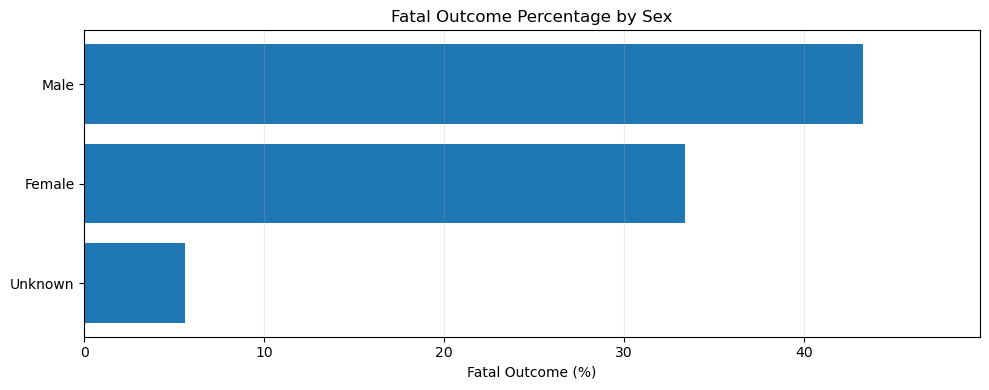

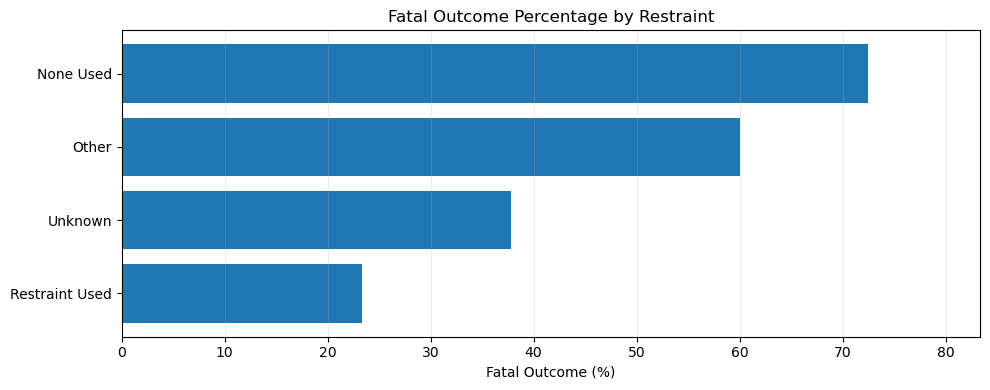

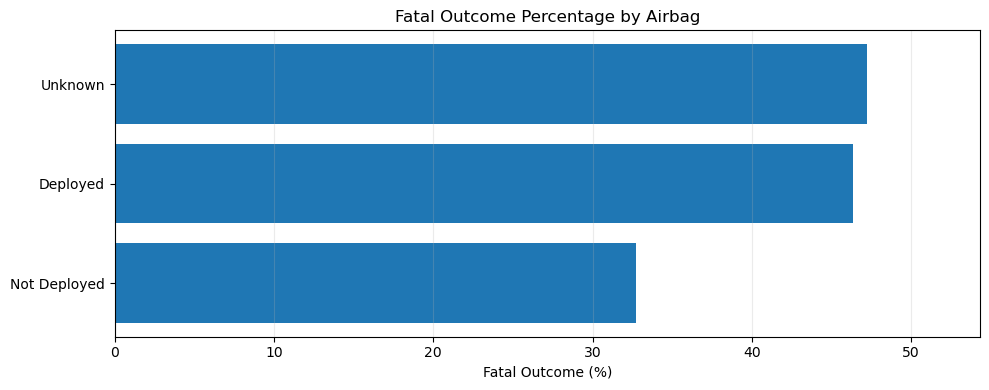

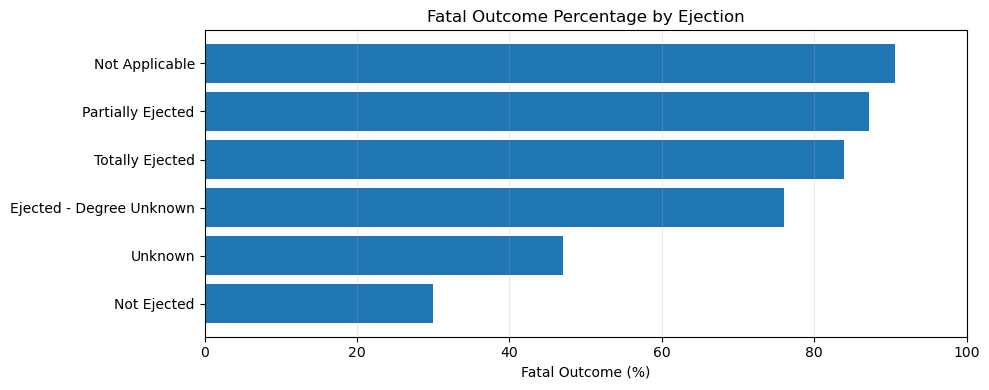

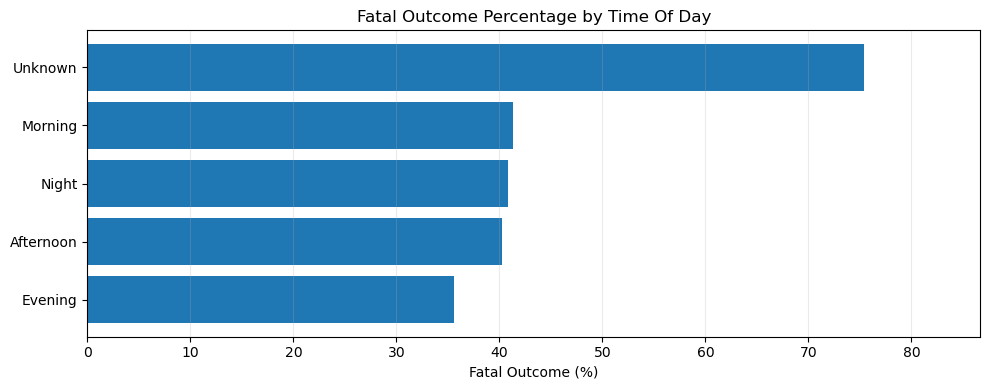

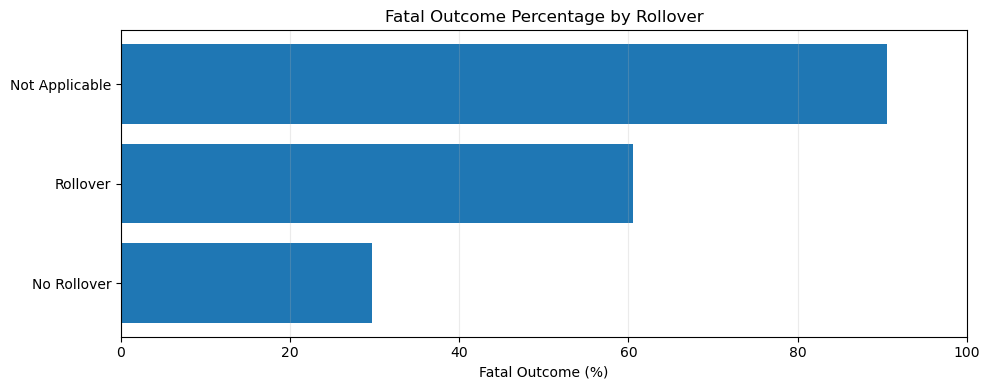

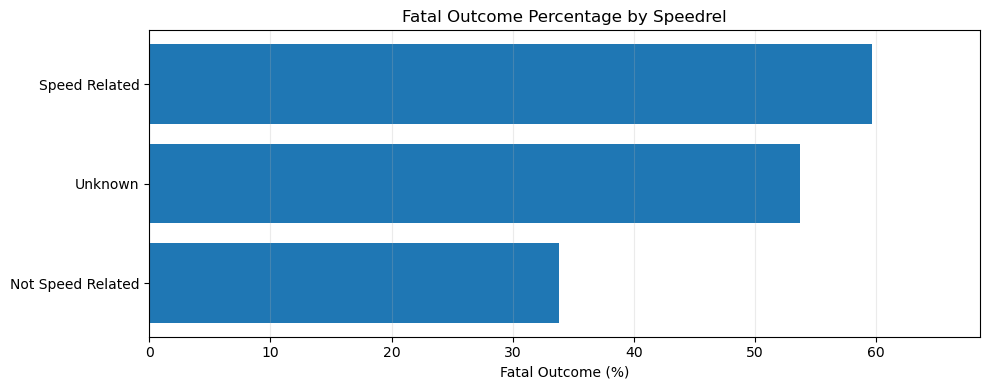

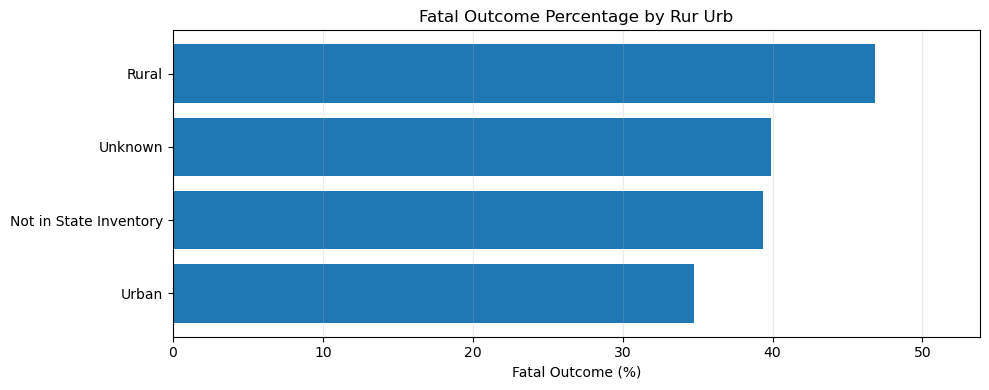

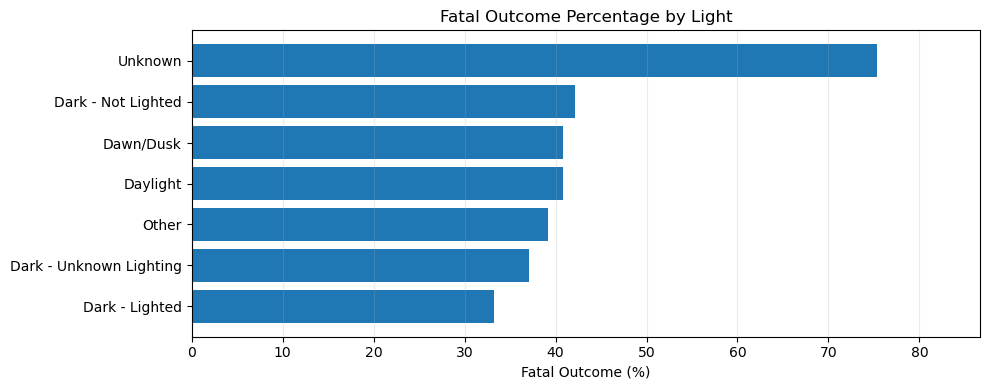

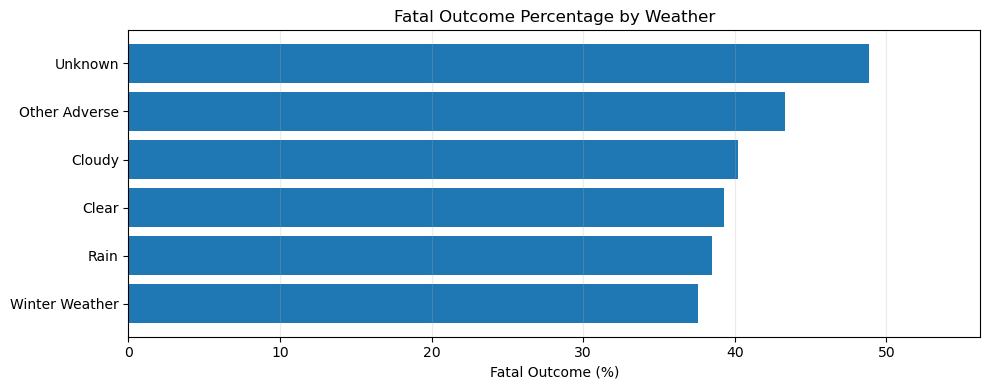

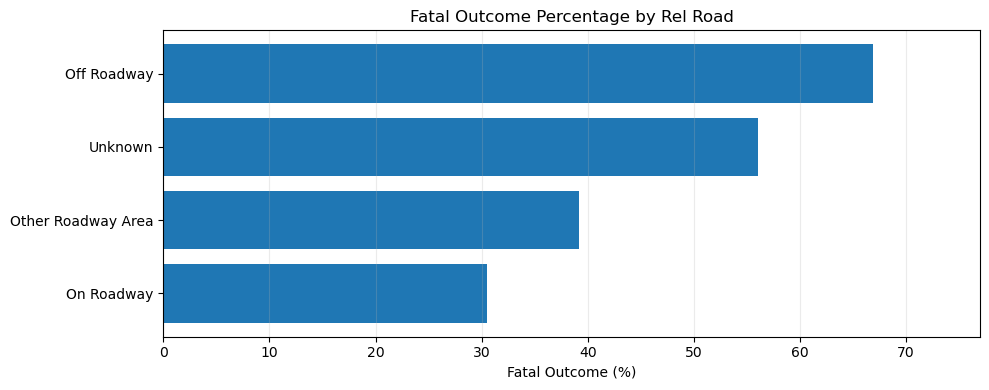

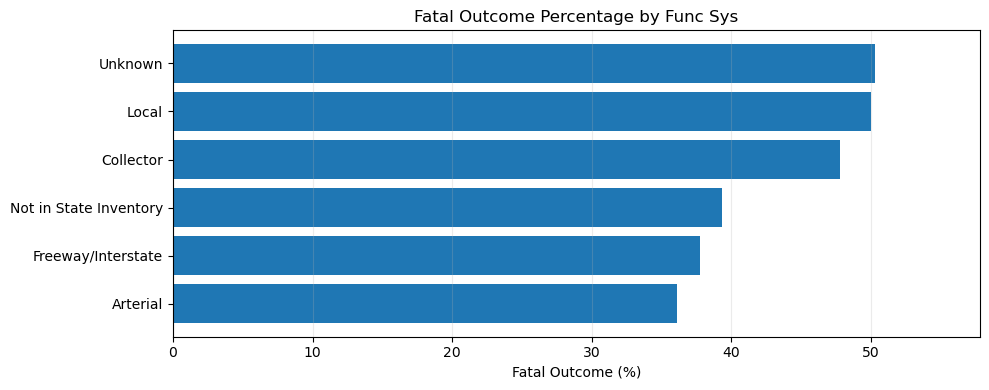

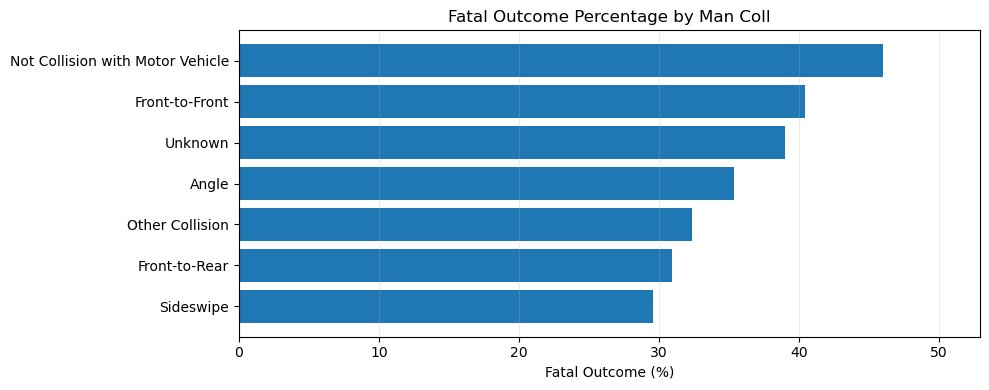

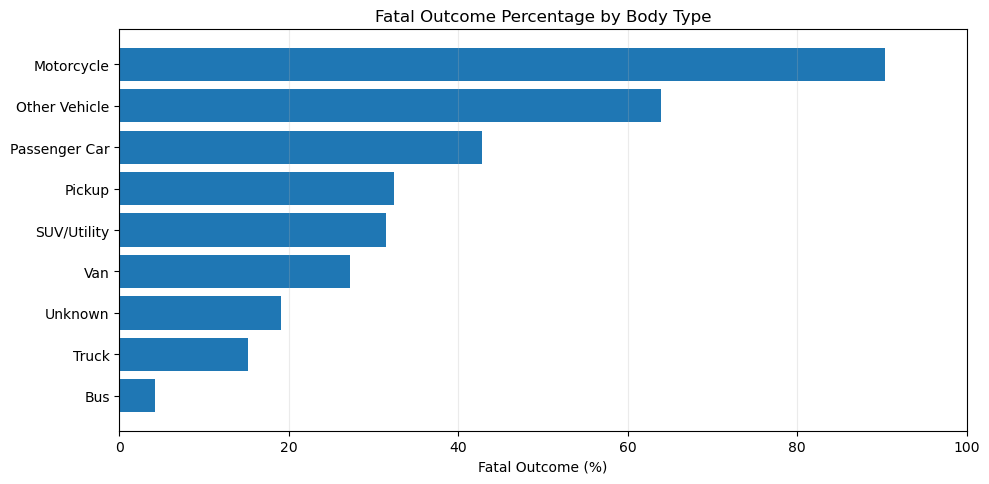

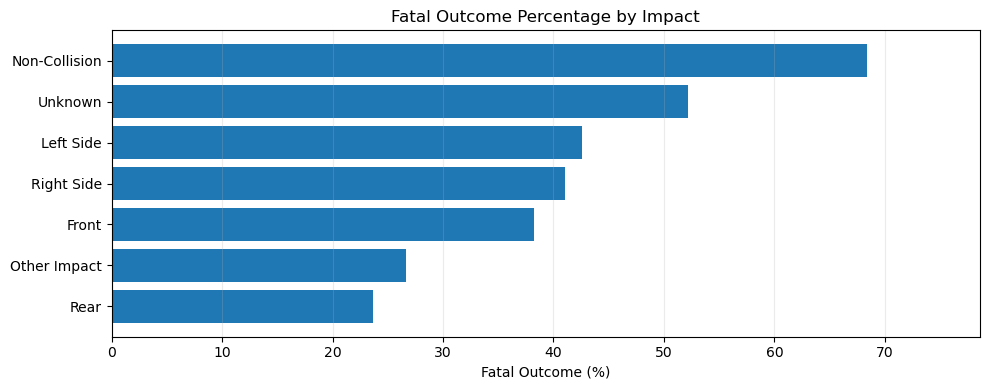

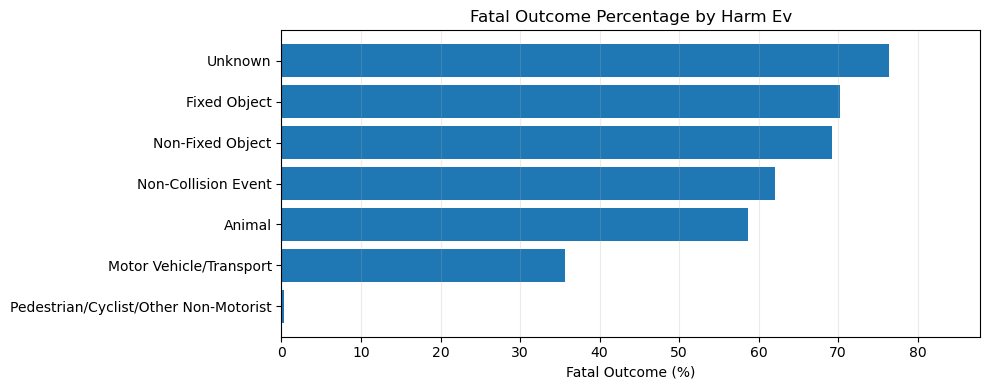

In [75]:
import matplotlib.pyplot as plt

for col in grouped_variables:
    
    plot_data = (
        fars_fatal_summary[
            fars_fatal_summary["Variable"] == col
        ]
        .sort_values("Fatal_Percentage", ascending=True)
    )

    fig, ax = plt.subplots(
        figsize=(10, max(4, len(plot_data) * 0.55))
    )

    ax.barh(
        plot_data["Category"].astype(str),
        plot_data["Fatal_Percentage"]
    )

    ax.set_title(
        f"Fatal Outcome Percentage by {col.replace('_GROUP', '').replace('_', ' ').title()}"
    )
    ax.set_xlabel("Fatal Outcome (%)")
    ax.set_ylabel("")

    ax.set_xlim(
        0,
        min(100, max(plot_data["Fatal_Percentage"]) * 1.15)
    )

    ax.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

### Ranked Substantive FARS Relationships

To focus the exploratory analysis on interpretable patterns, categories representing unknown, unreported, or not-applicable values were excluded from the ranked comparison. Categories with fewer than 500 observations were also excluded to reduce the influence of very small groups with potentially unstable percentages. A minimum count of 500 was used as an exploratory screening threshold rather than as a formal statistical significance criterion.

For each grouped variable, the range in fatal-outcome percentage was calculated as the difference between its highest and lowest remaining category. Larger ranges indicate stronger descriptive separation between categories within the FARS modeling population. These differences represent associations within fatal crashes and do not establish causation or population-level crash risk.

In [76]:
MIN_CATEGORY_COUNT = 500

excluded_categories = [
    "Unknown",
    "Not Applicable",
    "Not in State Inventory",
    "Other"
]

fars_substantive = fars_fatal_summary[
    (~fars_fatal_summary["Category"].isin(excluded_categories)) &
    (fars_fatal_summary["Total"] >= MIN_CATEGORY_COUNT)
].copy()

# Rank categories within each variable by fatal percentage
fars_substantive["Category_Rank"] = (
    fars_substantive
    .groupby("Variable")["Fatal_Percentage"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

fars_ranked_categories = (
    fars_substantive
    .sort_values(
        ["Variable", "Fatal_Percentage"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(
    fars_ranked_categories[
        [
            "Variable",
            "Category",
            "Total",
            "Fatal",
            "Nonfatal",
            "Fatal_Percentage",
            "Category_Rank"
        ]
    ]
)

print(
    "Categories retained:",
    len(fars_ranked_categories)
)

,Variable,Category,Total,Fatal,Nonfatal,Fatal_Percentage,Category_Rank
0,AIRBAG_GROUP,Deployed,35440,16433,19007,46.37,1
1,AIRBAG_GROUP,Not Deployed,38256,12530,25726,32.75,2
2,BODY_TYPE_GROUP,Motorcycle,6889,6225,664,90.36,1
3,BODY_TYPE_GROUP,Other Vehicle,995,636,359,63.92,2
4,BODY_TYPE_GROUP,Passenger Car,27209,11659,15550,42.85,3
5,BODY_TYPE_GROUP,Pickup,13155,4263,8892,32.41,4
6,BODY_TYPE_GROUP,SUV/Utility,19120,6012,13108,31.44,5
7,BODY_TYPE_GROUP,Van,3339,908,2431,27.19,6
8,BODY_TYPE_GROUP,Truck,5406,821,4585,15.19,7
9,BODY_TYPE_GROUP,Bus,600,25,575,4.17,8


Categories retained: 58


In [77]:
relationship_summary = (
    fars_substantive
    .groupby("Variable")
    .agg(
        Categories_Compared=("Category", "nunique"),
        Lowest_Fatal_Pct=("Fatal_Percentage", "min"),
        Highest_Fatal_Pct=("Fatal_Percentage", "max")
    )
    .reset_index()
)

relationship_summary["Percentage_Point_Spread"] = (
    relationship_summary["Highest_Fatal_Pct"] -
    relationship_summary["Lowest_Fatal_Pct"]
).round(2)

# Keep variables with at least two substantive categories
relationship_summary = (
    relationship_summary[
        relationship_summary["Categories_Compared"] >= 2
    ]
    .sort_values(
        "Percentage_Point_Spread",
        ascending=False
    )
    .reset_index(drop=True)
)

relationship_summary.insert(
    0,
    "Rank",
    range(1, len(relationship_summary) + 1)
)

display(relationship_summary)

,Rank,Variable,Categories_Compared,Lowest_Fatal_Pct,Highest_Fatal_Pct,Percentage_Point_Spread
0,1,BODY_TYPE_GROUP,8,4.17,90.36,86.19
1,2,HARM_EV_GROUP,4,0.28,70.25,69.97
2,3,EJECTION_GROUP,3,29.97,87.16,57.19
3,4,RESTRAINT_GROUP,2,23.36,72.47,49.11
4,5,IMPACT_GROUP,6,23.63,68.36,44.73
5,6,REL_ROAD_GROUP,2,30.55,66.93,36.38
6,7,ROLLOVER_GROUP,2,29.74,60.49,30.75
7,8,SPEEDREL_GROUP,2,33.82,59.62,25.80
8,9,MAN_COLL_GROUP,5,29.59,46.04,16.45
9,10,FUNC_SYS_GROUP,4,36.11,49.97,13.86


In [78]:
strongest_relationships = []

for variable in relationship_summary["Variable"]:
    
    temp = fars_substantive[
        fars_substantive["Variable"] == variable
    ]
    
    high = temp.loc[temp["Fatal_Percentage"].idxmax()]
    low = temp.loc[temp["Fatal_Percentage"].idxmin()]
    
    strongest_relationships.append({
        "Variable": variable,
        "Highest_Category": high["Category"],
        "Highest_Fatal_Pct": high["Fatal_Percentage"],
        "Lowest_Category": low["Category"],
        "Lowest_Fatal_Pct": low["Fatal_Percentage"],
        "Percentage_Point_Spread": round(
            high["Fatal_Percentage"] -
            low["Fatal_Percentage"],
            2
        )
    })

strongest_relationships = (
    pd.DataFrame(strongest_relationships)
    .sort_values(
        "Percentage_Point_Spread",
        ascending=False
    )
    .reset_index(drop=True)
)

display(strongest_relationships)

,Variable,Highest_Category,Highest_Fatal_Pct,Lowest_Category,Lowest_Fatal_Pct,Percentage_Point_Spread
0,BODY_TYPE_GROUP,Motorcycle,90.36,Bus,4.17,86.19
1,HARM_EV_GROUP,Fixed Object,70.25,Pedestrian/Cyclist/Other Non-Motorist,0.28,69.97
2,EJECTION_GROUP,Partially Ejected,87.16,Not Ejected,29.97,57.19
3,RESTRAINT_GROUP,None Used,72.47,Restraint Used,23.36,49.11
4,IMPACT_GROUP,Non-Collision,68.36,Rear,23.63,44.73
5,REL_ROAD_GROUP,Off Roadway,66.93,On Roadway,30.55,36.38
6,ROLLOVER_GROUP,Rollover,60.49,No Rollover,29.74,30.75
7,SPEEDREL_GROUP,Speed Related,59.62,Not Speed Related,33.82,25.80
8,MAN_COLL_GROUP,Not Collision with Motor Vehicle,46.04,Sideswipe,29.59,16.45
9,FUNC_SYS_GROUP,Local,49.97,Arterial,36.11,13.86


### Confidence Intervals and Stability Assessment

To evaluate the precision of the descriptive fatal-outcome percentages, 95% Wilson confidence intervals were calculated for each retained category. Category sample size and confidence-interval width were also used as diagnostic measures of estimate stability. Categories with fewer than 500 observations or relatively wide confidence intervals were flagged for cautious interpretation. These intervals quantify sampling uncertainty in the observed proportions but do not remove limitations associated with the FARS population, variable coding, or observational study design.

In [79]:
from statsmodels.stats.proportion import proportion_confint

MIN_SAMPLE_SIZE = 500
MIN_FATAL_COUNT = 20
WIDE_CI_THRESHOLD = 10.0  # percentage points

fars_ci_summary = fars_fatal_summary.copy()

ci_lower = []
ci_upper = []

for _, row in fars_ci_summary.iterrows():
    
    low, high = proportion_confint(
        count=int(row["Fatal"]),
        nobs=int(row["Total"]),
        alpha=0.05,
        method="wilson"
    )
    
    ci_lower.append(low * 100)
    ci_upper.append(high * 100)

fars_ci_summary["CI_Lower_95"] = (
    pd.Series(ci_lower).round(2)
)

fars_ci_summary["CI_Upper_95"] = (
    pd.Series(ci_upper).round(2)
)

fars_ci_summary["CI_Width"] = (
    fars_ci_summary["CI_Upper_95"] -
    fars_ci_summary["CI_Lower_95"]
).round(2)

# Stability checks
fars_ci_summary["Meets_Min_Sample"] = (
    fars_ci_summary["Total"] >= MIN_SAMPLE_SIZE
)

fars_ci_summary["Meets_Min_Fatal_Count"] = (
    fars_ci_summary["Fatal"] >= MIN_FATAL_COUNT
)

fars_ci_summary["Wide_CI"] = (
    fars_ci_summary["CI_Width"] > WIDE_CI_THRESHOLD
)

fars_ci_summary["Potentially_Unstable"] = (
    (~fars_ci_summary["Meets_Min_Sample"]) |
    (~fars_ci_summary["Meets_Min_Fatal_Count"]) |
    fars_ci_summary["Wide_CI"]
)

display(
    fars_ci_summary[
        [
            "Variable",
            "Category",
            "Total",
            "Fatal",
            "Fatal_Percentage",
            "CI_Lower_95",
            "CI_Upper_95",
            "CI_Width",
            "Meets_Min_Sample",
            "Meets_Min_Fatal_Count",
            "Wide_CI",
            "Potentially_Unstable"
        ]
    ]
)

,Variable,Category,Total,Fatal,Fatal_Percentage,CI_Lower_95,CI_Upper_95,CI_Width,Meets_Min_Sample,Meets_Min_Fatal_Count,Wide_CI,Potentially_Unstable
0,SEX_GROUP,Female,25080,8379,33.41,32.83,34.00,1.17,True,True,False,False
1,SEX_GROUP,Male,51350,22231,43.29,42.87,43.72,0.85,True,True,False,False
2,SEX_GROUP,Unknown,855,48,5.61,4.26,7.36,3.10,True,True,False,False
3,RESTRAINT_GROUP,None Used,23472,17011,72.47,71.90,73.04,1.14,True,True,False,False
4,RESTRAINT_GROUP,Other,35,21,60.00,43.57,74.45,30.88,False,True,True,True
5,RESTRAINT_GROUP,Restraint Used,46416,10842,23.36,22.98,23.75,0.77,True,True,False,False
6,RESTRAINT_GROUP,Unknown,7362,2784,37.82,36.71,38.93,2.22,True,True,False,False
7,AIRBAG_GROUP,Deployed,35440,16433,46.37,45.85,46.89,1.04,True,True,False,False
8,AIRBAG_GROUP,Not Deployed,38256,12530,32.75,32.28,33.23,0.95,True,True,False,False
9,AIRBAG_GROUP,Unknown,3589,1695,47.23,45.60,48.86,3.26,True,True,False,False


In [80]:
excluded_categories = [
    "Unknown",
    "Not Applicable",
    "Not in State Inventory",
    "Other"
]

fars_ranked_ci = fars_ci_summary[
    (~fars_ci_summary["Category"].isin(excluded_categories)) &
    (fars_ci_summary["Meets_Min_Sample"]) &
    (fars_ci_summary["Meets_Min_Fatal_Count"])
].copy()

fars_ranked_ci = (
    fars_ranked_ci
    .sort_values(
        ["Variable", "Fatal_Percentage"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

fars_ranked_ci["Category_Rank"] = (
    fars_ranked_ci
    .groupby("Variable")["Fatal_Percentage"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

display(
    fars_ranked_ci[
        [
            "Variable",
            "Category",
            "Total",
            "Fatal",
            "Fatal_Percentage",
            "CI_Lower_95",
            "CI_Upper_95",
            "CI_Width",
            "Potentially_Unstable",
            "Category_Rank"
        ]
    ]
)

,Variable,Category,Total,Fatal,Fatal_Percentage,CI_Lower_95,CI_Upper_95,CI_Width,Potentially_Unstable,Category_Rank
0,AIRBAG_GROUP,Deployed,35440,16433,46.37,45.85,46.89,1.04,False,1
1,AIRBAG_GROUP,Not Deployed,38256,12530,32.75,32.28,33.23,0.95,False,2
2,BODY_TYPE_GROUP,Motorcycle,6889,6225,90.36,89.64,91.04,1.40,False,1
3,BODY_TYPE_GROUP,Other Vehicle,995,636,63.92,60.89,66.84,5.95,False,2
4,BODY_TYPE_GROUP,Passenger Car,27209,11659,42.85,42.26,43.44,1.18,False,3
5,BODY_TYPE_GROUP,Pickup,13155,4263,32.41,31.61,33.21,1.60,False,4
6,BODY_TYPE_GROUP,SUV/Utility,19120,6012,31.44,30.79,32.11,1.32,False,5
7,BODY_TYPE_GROUP,Van,3339,908,27.19,25.71,28.73,3.02,False,6
8,BODY_TYPE_GROUP,Truck,5406,821,15.19,14.25,16.17,1.92,False,7
9,BODY_TYPE_GROUP,Bus,600,25,4.17,2.84,6.08,3.24,False,8


In [81]:
unstable_categories = fars_ci_summary[
    fars_ci_summary["Potentially_Unstable"]
].copy()

def instability_reason(row):
    reasons = []
    
    if not row["Meets_Min_Sample"]:
        reasons.append("Small total sample")
        
    if not row["Meets_Min_Fatal_Count"]:
        reasons.append("Few fatal outcomes")
        
    if row["Wide_CI"]:
        reasons.append("Wide confidence interval")
    
    return "; ".join(reasons)

unstable_categories["Instability_Reason"] = (
    unstable_categories.apply(
        instability_reason,
        axis=1
    )
)

print("Minimum total sample:", MIN_SAMPLE_SIZE)
print("Minimum fatal outcomes:", MIN_FATAL_COUNT)
print(
    "Wide CI threshold:",
    f"{WIDE_CI_THRESHOLD} percentage points"
)
print(
    "Potentially unstable categories:",
    len(unstable_categories)
)

display(
    unstable_categories[
        [
            "Variable",
            "Category",
            "Total",
            "Fatal",
            "Fatal_Percentage",
            "CI_Lower_95",
            "CI_Upper_95",
            "CI_Width",
            "Instability_Reason"
        ]
    ].sort_values(["Total", "Fatal"])
)

Minimum total sample: 500
Minimum fatal outcomes: 20
Wide CI threshold: 10.0 percentage points
Potentially unstable categories: 16


,Variable,Category,Total,Fatal,Fatal_Percentage,CI_Lower_95,CI_Upper_95,CI_Width,Instability_Reason
36,LIGHT_GROUP,Other,23,9,39.13,22.16,59.21,37.05,Small total sample; Few fatal outcomes; Wide c...
4,RESTRAINT_GROUP,Other,35,21,60.00,43.57,74.45,30.88,Small total sample; Wide confidence interval
10,EJECTION_GROUP,Ejected - Degree Unknown,71,54,76.06,64.96,84.48,19.52,Small total sample; Wide confidence interval
83,HARM_EV_GROUP,Unknown,72,55,76.39,65.40,84.70,19.30,Small total sample; Wide confidence interval
47,REL_ROAD_GROUP,Unknown,182,102,56.04,48.78,63.06,14.28,Small total sample; Wide confidence interval
27,RUR_URB_GROUP,Not in State Inventory,183,72,39.34,32.56,46.57,14.01,Small total sample; Wide confidence interval
52,FUNC_SYS_GROUP,Not in State Inventory,183,72,39.34,32.56,46.57,14.01,Small total sample; Wide confidence interval
60,MAN_COLL_GROUP,Unknown,218,85,38.99,32.76,45.60,12.84,Small total sample; Wide confidence interval
46,REL_ROAD_GROUP,Other Roadway Area,273,107,39.19,33.59,45.10,11.51,Small total sample; Wide confidence interval
37,LIGHT_GROUP,Unknown,276,208,75.36,69.95,80.07,10.12,Small total sample; Wide confidence interval


In [82]:
def classify_stability(row):
    failed_checks = 0

    if row["Total"] < MIN_SAMPLE_SIZE:
        failed_checks += 1

    if row["Fatal"] < MIN_FATAL_COUNT:
        failed_checks += 1

    if row["CI_Width"] > WIDE_CI_THRESHOLD:
        failed_checks += 1

    if failed_checks == 0:
        return "Stable"
    elif failed_checks == 1:
        return "Caution"
    else:
        return "Unstable"


fars_ci_summary["Stability"] = (
    fars_ci_summary.apply(
        classify_stability,
        axis=1
    )
)

display(
    fars_ci_summary[
        [
            "Variable",
            "Category",
            "Total",
            "Fatal",
            "Fatal_Percentage",
            "CI_Lower_95",
            "CI_Upper_95",
            "CI_Width",
            "Stability"
        ]
    ]
)

,Variable,Category,Total,Fatal,Fatal_Percentage,CI_Lower_95,CI_Upper_95,CI_Width,Stability
0,SEX_GROUP,Female,25080,8379,33.41,32.83,34.00,1.17,Stable
1,SEX_GROUP,Male,51350,22231,43.29,42.87,43.72,0.85,Stable
2,SEX_GROUP,Unknown,855,48,5.61,4.26,7.36,3.10,Stable
3,RESTRAINT_GROUP,None Used,23472,17011,72.47,71.90,73.04,1.14,Stable
4,RESTRAINT_GROUP,Other,35,21,60.00,43.57,74.45,30.88,Unstable
5,RESTRAINT_GROUP,Restraint Used,46416,10842,23.36,22.98,23.75,0.77,Stable
6,RESTRAINT_GROUP,Unknown,7362,2784,37.82,36.71,38.93,2.22,Stable
7,AIRBAG_GROUP,Deployed,35440,16433,46.37,45.85,46.89,1.04,Stable
8,AIRBAG_GROUP,Not Deployed,38256,12530,32.75,32.28,33.23,0.95,Stable
9,AIRBAG_GROUP,Unknown,3589,1695,47.23,45.60,48.86,3.26,Stable


In [83]:
stability_counts = (
    fars_ci_summary["Stability"]
    .value_counts()
    .reindex(
        ["Stable", "Caution", "Unstable"],
        fill_value=0
    )
)

display(
    stability_counts.to_frame("Categories")
)

assert stability_counts.sum() == len(fars_ci_summary)

print(
    "All categories received a stability classification."
)

,Categories
Stability,
Stable,68
Caution,4
Unstable,12


All categories received a stability classification.


In [84]:
excluded_categories = [
    "Unknown",
    "Not Applicable",
    "Not in State Inventory",
    "Other"
]

fars_ranked_ci = fars_ci_summary[
    ~fars_ci_summary["Category"].isin(
        excluded_categories
    )
].copy()

fars_ranked_ci["Category_Rank"] = (
    fars_ranked_ci
    .groupby("Variable")["Fatal_Percentage"]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)

fars_ranked_ci = (
    fars_ranked_ci
    .sort_values(
        ["Variable", "Fatal_Percentage"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(
    fars_ranked_ci[
        [
            "Variable",
            "Category",
            "Total",
            "Fatal",
            "Fatal_Percentage",
            "CI_Lower_95",
            "CI_Upper_95",
            "CI_Width",
            "Stability",
            "Category_Rank"
        ]
    ]
)

,Variable,Category,Total,Fatal,Fatal_Percentage,CI_Lower_95,CI_Upper_95,CI_Width,Stability,Category_Rank
0,AIRBAG_GROUP,Deployed,35440,16433,46.37,45.85,46.89,1.04,Stable,1
1,AIRBAG_GROUP,Not Deployed,38256,12530,32.75,32.28,33.23,0.95,Stable,2
2,BODY_TYPE_GROUP,Motorcycle,6889,6225,90.36,89.64,91.04,1.40,Stable,1
3,BODY_TYPE_GROUP,Other Vehicle,995,636,63.92,60.89,66.84,5.95,Stable,2
4,BODY_TYPE_GROUP,Passenger Car,27209,11659,42.85,42.26,43.44,1.18,Stable,3
5,BODY_TYPE_GROUP,Pickup,13155,4263,32.41,31.61,33.21,1.60,Stable,4
6,BODY_TYPE_GROUP,SUV/Utility,19120,6012,31.44,30.79,32.11,1.32,Stable,5
7,BODY_TYPE_GROUP,Van,3339,908,27.19,25.71,28.73,3.02,Stable,6
8,BODY_TYPE_GROUP,Truck,5406,821,15.19,14.25,16.17,1.92,Stable,7
9,BODY_TYPE_GROUP,Bus,600,25,4.17,2.84,6.08,3.24,Stable,8


In [85]:
stable_results = fars_ranked_ci[
    fars_ranked_ci["Stability"] == "Stable"
].copy()

strongest_relationships = []

for variable in stable_results["Variable"].unique():

    temp = stable_results[
        stable_results["Variable"] == variable
    ]

    # A relationship requires at least two categories
    if len(temp) < 2:
        continue

    high = temp.loc[
        temp["Fatal_Percentage"].idxmax()
    ]

    low = temp.loc[
        temp["Fatal_Percentage"].idxmin()
    ]

    strongest_relationships.append({
        "Variable": variable,
        "Highest_Category": high["Category"],
        "Highest_Fatal_Pct": high["Fatal_Percentage"],
        "Highest_N": int(high["Total"]),
        "Lowest_Category": low["Category"],
        "Lowest_Fatal_Pct": low["Fatal_Percentage"],
        "Lowest_N": int(low["Total"]),
        "Percentage_Point_Spread": round(
            high["Fatal_Percentage"] -
            low["Fatal_Percentage"],
            2
        )
    })

strongest_relationships = (
    pd.DataFrame(strongest_relationships)
    .sort_values(
        "Percentage_Point_Spread",
        ascending=False
    )
    .reset_index(drop=True)
)

strongest_relationships.insert(
    0,
    "Rank",
    range(1, len(strongest_relationships) + 1)
)

display(strongest_relationships)

,Rank,Variable,Highest_Category,Highest_Fatal_Pct,Highest_N,Lowest_Category,Lowest_Fatal_Pct,Lowest_N,Percentage_Point_Spread
0,1,BODY_TYPE_GROUP,Motorcycle,90.36,6889,Bus,4.17,600,86.19
1,2,HARM_EV_GROUP,Fixed Object,70.25,15023,Pedestrian/Cyclist/Other Non-Motorist,0.28,10067,69.97
2,3,EJECTION_GROUP,Partially Ejected,87.16,1090,Not Ejected,29.97,63786,57.19
3,4,RESTRAINT_GROUP,None Used,72.47,23472,Restraint Used,23.36,46416,49.11
4,5,IMPACT_GROUP,Non-Collision,68.36,4080,Rear,23.63,6504,44.73
5,6,REL_ROAD_GROUP,Off Roadway,66.93,19177,On Roadway,30.55,57653,36.38
6,7,ROLLOVER_GROUP,Rollover,60.49,11702,No Rollover,29.74,58895,30.75
7,8,SPEEDREL_GROUP,Speed Related,59.62,14593,Not Speed Related,33.82,58884,25.80
8,9,MAN_COLL_GROUP,Not Collision with Motor Vehicle,46.04,31278,Sideswipe,29.59,3630,16.45
9,10,FUNC_SYS_GROUP,Local,49.97,6302,Arterial,36.11,43086,13.86


### Sanity Check of the Strongest Descriptive Relationships

The five grouped variables with the largest percentage-point spreads were examined in greater detail before further statistical analysis. Total observations, fatal and nonfatal outcomes, fatal-outcome percentages, and 95% Wilson confidence intervals were reviewed for each substantive category. This step was used to verify that the largest descriptive differences were supported by adequate observations and were not driven primarily by sparse categories or unstable estimates.

Special attention was given to the grouped first harmful event variable because its categories describe the crash event rather than characteristics known before the crash. Results for this variable therefore require careful interpretation and should not be treated as estimates of pre-crash risk.

In [86]:
top_five_variables = (
    strongest_relationships
    .head(5)["Variable"]
    .tolist()
)

top_five_check = fars_ci_summary[
    fars_ci_summary["Variable"].isin(top_five_variables)
].copy()

excluded_categories = [
    "Unknown",
    "Not Applicable",
    "Not in State Inventory",
    "Other"
]

top_five_check = top_five_check[
    ~top_five_check["Category"].isin(excluded_categories)
].copy()

top_five_check["Nonfatal"] = (
    top_five_check["Total"] -
    top_five_check["Fatal"]
)

top_five_check["Variable_Order"] = (
    top_five_check["Variable"]
    .map({
        variable: rank
        for rank, variable
        in enumerate(top_five_variables, start=1)
    })
)

top_five_check = (
    top_five_check
    .sort_values(
        ["Variable_Order", "Fatal_Percentage"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(
    top_five_check[
        [
            "Variable",
            "Category",
            "Total",
            "Fatal",
            "Nonfatal",
            "Fatal_Percentage",
            "CI_Lower_95",
            "CI_Upper_95",
            "CI_Width",
            "Stability"
        ]
    ]
)

,Variable,Category,Total,Fatal,Nonfatal,Fatal_Percentage,CI_Lower_95,CI_Upper_95,CI_Width,Stability
0,BODY_TYPE_GROUP,Motorcycle,6889,6225,664,90.36,89.64,91.04,1.40,Stable
1,BODY_TYPE_GROUP,Other Vehicle,995,636,359,63.92,60.89,66.84,5.95,Stable
2,BODY_TYPE_GROUP,Passenger Car,27209,11659,15550,42.85,42.26,43.44,1.18,Stable
3,BODY_TYPE_GROUP,Pickup,13155,4263,8892,32.41,31.61,33.21,1.60,Stable
4,BODY_TYPE_GROUP,SUV/Utility,19120,6012,13108,31.44,30.79,32.11,1.32,Stable
5,BODY_TYPE_GROUP,Van,3339,908,2431,27.19,25.71,28.73,3.02,Stable
6,BODY_TYPE_GROUP,Truck,5406,821,4585,15.19,14.25,16.17,1.92,Stable
7,BODY_TYPE_GROUP,Bus,600,25,575,4.17,2.84,6.08,3.24,Stable
8,HARM_EV_GROUP,Fixed Object,15023,10554,4469,70.25,69.52,70.98,1.46,Stable
9,HARM_EV_GROUP,Non-Fixed Object,442,306,136,69.23,64.78,73.35,8.57,Caution


In [87]:
harm_ev_check = (
    fars_ci_summary[
        fars_ci_summary["Variable"] == "HARM_EV_GROUP"
    ]
    .copy()
)

harm_ev_check["Nonfatal"] = (
    harm_ev_check["Total"] -
    harm_ev_check["Fatal"]
)

harm_ev_check = (
    harm_ev_check
    .sort_values(
        "Fatal_Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    harm_ev_check[
        [
            "Category",
            "Total",
            "Fatal",
            "Nonfatal",
            "Fatal_Percentage",
            "CI_Lower_95",
            "CI_Upper_95",
            "CI_Width",
            "Stability"
        ]
    ]
)

print(
    "HARM_EV_GROUP total records:",
    f"{harm_ev_check['Total'].sum():,}"
)

assert harm_ev_check["Total"].sum() == 77285

print("HARM_EV_GROUP passed total-record validation.")

,Category,Total,Fatal,Nonfatal,Fatal_Percentage,CI_Lower_95,CI_Upper_95,CI_Width,Stability
0,Unknown,72,55,17,76.39,65.40,84.70,19.30,Unstable
1,Fixed Object,15023,10554,4469,70.25,69.52,70.98,1.46,Stable
2,Non-Fixed Object,442,306,136,69.23,64.78,73.35,8.57,Caution
3,Non-Collision Event,4462,2768,1694,62.03,60.60,63.45,2.85,Stable
4,Animal,353,207,146,58.64,53.44,63.66,10.22,Unstable
5,Motor Vehicle/Transport,46866,16740,30126,35.72,35.29,36.15,0.86,Stable
6,Pedestrian/Cyclist/Other Non-Motorist,10067,28,10039,0.28,0.19,0.40,0.21,Stable


HARM_EV_GROUP total records: 77,285
HARM_EV_GROUP passed total-record validation.


In [88]:
harm_special_check = harm_ev_check[
    harm_ev_check["Category"] ==
    "Pedestrian/Cyclist/Other Non-Motorist"
]

display(
    harm_special_check[
        [
            "Category",
            "Total",
            "Fatal",
            "Nonfatal",
            "Fatal_Percentage",
            "CI_Lower_95",
            "CI_Upper_95",
            "Stability"
        ]
    ]
)

,Category,Total,Fatal,Nonfatal,Fatal_Percentage,CI_Lower_95,CI_Upper_95,Stability
6,Pedestrian/Cyclist/Other Non-Motorist,10067,28,10039,0.28,0.19,0.4,Stable


In [89]:
harm_pertyp_check = (
    fars_clean
    .groupby(
        ["HARM_EV_GROUP", "PER_TYP"],
        dropna=False
    )
    .agg(
        Total=("FATAL_OUTCOME", "size"),
        Fatal=("FATAL_OUTCOME", "sum")
    )
    .reset_index()
)

harm_pertyp_check["Nonfatal"] = (
    harm_pertyp_check["Total"] -
    harm_pertyp_check["Fatal"]
)

harm_pertyp_check["Fatal_Percentage"] = (
    harm_pertyp_check["Fatal"] /
    harm_pertyp_check["Total"] * 100
).round(2)

display(
    harm_pertyp_check[
        harm_pertyp_check["HARM_EV_GROUP"] ==
        "Pedestrian/Cyclist/Other Non-Motorist"
    ].sort_values(
        "Total",
        ascending=False
    )
)

,HARM_EV_GROUP,PER_TYP,Total,Fatal,Nonfatal,Fatal_Percentage
10,Pedestrian/Cyclist/Other Non-Motorist,1,7726,23,7703,0.30
11,Pedestrian/Cyclist/Other Non-Motorist,2,2341,5,2336,0.21


## Statistical Association Analysis

Chi-square tests of independence were used to evaluate associations between the grouped categorical variables and fatal outcome. Because the large FARS modeling population can produce statistically significant results even for relatively small differences, Cramér's V was also calculated to measure the strength of each association. These results are interpreted as descriptive associations within the FARS fatal-crash population and do not establish causation.

In [90]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

association_results = []

for variable in grouped_variables:
    contingency_table = pd.crosstab(
        fars_clean[variable],
        fars_clean["FATAL_OUTCOME"]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()
    r, k = contingency_table.shape

    cramers_v = np.sqrt(
        chi2 / (n * min(r - 1, k - 1))
    )

    association_results.append({
        "Variable": variable,
        "Chi_Square": chi2,
        "P_Value": p_value,
        "Degrees_of_Freedom": dof,
        "Cramers_V": cramers_v
    })

association_results = pd.DataFrame(
    association_results
).sort_values(
    "Cramers_V",
    ascending=False
).reset_index(drop=True)

association_results.insert(
    0,
    "Rank",
    range(1, len(association_results) + 1)
)

association_results["Chi_Square"] = (
    association_results["Chi_Square"].round(2)
)

association_results["Cramers_V"] = (
    association_results["Cramers_V"].round(4)
)

display(association_results)

print(
    "Variables tested:",
    len(association_results)
)

assert len(association_results) == len(grouped_variables)

print("All grouped variables passed association testing.")

,Rank,Variable,Chi_Square,P_Value,Degrees_of_Freedom,Cramers_V
0,1,RESTRAINT_GROUP,15730.54,0.000000e+00,3,0.4512
1,2,EJECTION_GROUP,14876.85,0.000000e+00,5,0.4387
2,3,HARM_EV_GROUP,13891.34,0.000000e+00,6,0.4240
3,4,ROLLOVER_GROUP,11800.33,0.000000e+00,2,0.3908
4,5,BODY_TYPE_GROUP,10575.52,0.000000e+00,8,0.3699
5,6,REL_ROAD_GROUP,7977.36,0.000000e+00,3,0.3213
6,7,SPEEDREL_GROUP,3582.85,0.000000e+00,2,0.2153
7,8,IMPACT_GROUP,2463.73,0.000000e+00,6,0.1785
8,9,AIRBAG_GROUP,1514.89,0.000000e+00,2,0.1400
9,10,MAN_COLL_GROUP,1143.40,8.504307e-244,6,0.1216


Variables tested: 16
All grouped variables passed association testing.


In [91]:
pre_crash_predictors = [
    "SEX_GROUP",
    "RESTRAINT_GROUP",
    "TIME_OF_DAY",
    "SPEEDREL_GROUP",
    "RUR_URB_GROUP",
    "LIGHT_GROUP",
    "WEATHER_GROUP",
    "FUNC_SYS_GROUP",
    "BODY_TYPE_GROUP"
]

crash_event_predictors = [
    "EJECTION_GROUP",
    "AIRBAG_GROUP",
    "ROLLOVER_GROUP",
    "IMPACT_GROUP",
    "HARM_EV_GROUP",
    "MAN_COLL_GROUP",
    "REL_ROAD_GROUP"
]

all_classified_predictors = (
    pre_crash_predictors +
    crash_event_predictors
)

assert len(all_classified_predictors) == 16
assert set(all_classified_predictors) == set(grouped_variables)

print("Pre-Crash / Available Characteristics")
display(pd.DataFrame({
    "Predictor": pre_crash_predictors
}))

print("Crash-Event Characteristics")
display(pd.DataFrame({
    "Predictor": crash_event_predictors
}))

print(
    "Total predictors classified:",
    len(all_classified_predictors)
)

Pre-Crash / Available Characteristics


,Predictor
0,SEX_GROUP
1,RESTRAINT_GROUP
2,TIME_OF_DAY
3,SPEEDREL_GROUP
4,RUR_URB_GROUP
5,LIGHT_GROUP
6,WEATHER_GROUP
7,FUNC_SYS_GROUP
8,BODY_TYPE_GROUP


Crash-Event Characteristics


,Predictor
0,EJECTION_GROUP
1,AIRBAG_GROUP
2,ROLLOVER_GROUP
3,IMPACT_GROUP
4,HARM_EV_GROUP
5,MAN_COLL_GROUP
6,REL_ROAD_GROUP


Total predictors classified: 16


In [92]:
model_columns = pre_crash_predictors + ["FATAL_OUTCOME"]

fars_precrash_model = fars_clean[
    model_columns
].copy()

fars_precrash_model[
    pre_crash_predictors
] = fars_precrash_model[
    pre_crash_predictors
].fillna("Unknown")

fars_precrash_model = fars_precrash_model.dropna(
    subset=["FATAL_OUTCOME"]
).reset_index(drop=True)

print(
    "Modeling dataset shape:",
    fars_precrash_model.shape
)

print(
    "Missing values:",
    fars_precrash_model.isna().sum().sum()
)

print(
    "Modeling columns:"
)

display(
    pd.DataFrame({
        "Column": fars_precrash_model.columns
    })
)

assert fars_precrash_model.shape[1] == 10
assert fars_precrash_model.isna().sum().sum() == 0

Modeling dataset shape: (77285, 10)
Missing values: 0
Modeling columns:


,Column
0,SEX_GROUP
1,RESTRAINT_GROUP
2,TIME_OF_DAY
3,SPEEDREL_GROUP
4,RUR_URB_GROUP
5,LIGHT_GROUP
6,WEATHER_GROUP
7,FUNC_SYS_GROUP
8,BODY_TYPE_GROUP
9,FATAL_OUTCOME


In [93]:
X = fars_precrash_model[
    pre_crash_predictors
].copy()

y = fars_precrash_model[
    "FATAL_OUTCOME"
].copy()

X_encoded = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print("Original predictor shape:", X.shape)
print("Encoded predictor shape:", X_encoded.shape)
print("Target shape:", y.shape)

display(
    pd.DataFrame({
        "Encoded_Feature": X_encoded.columns
    })
)

assert len(X_encoded) == len(y)
assert X_encoded.isna().sum().sum() == 0

Original predictor shape: (77285, 9)
Encoded predictor shape: (77285, 38)
Target shape: (77285,)


,Encoded_Feature
0,SEX_GROUP_Male
1,SEX_GROUP_Unknown
2,RESTRAINT_GROUP_Other
3,RESTRAINT_GROUP_Restraint Used
4,RESTRAINT_GROUP_Unknown
5,TIME_OF_DAY_Evening
6,TIME_OF_DAY_Morning
7,TIME_OF_DAY_Night
8,TIME_OF_DAY_Unknown
9,SPEEDREL_GROUP_Speed Related


In [94]:
from sklearn.model_selection import GroupShuffleSplit

groups = fars_clean.loc[
    fars_precrash_model.index,
    "ST_CASE"
].reset_index(drop=True)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X_encoded,
        y,
        groups=groups
    )
)

X_train = X_encoded.iloc[train_idx]
X_test = X_encoded.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print(
    "Training fatal percentage:",
    round(y_train.mean() * 100, 2)
)

print(
    "Testing fatal percentage:",
    round(y_test.mean() * 100, 2)
)

print(
    "Shared crashes:",
    len(
        set(groups_train).intersection(
            set(groups_test)
        )
    )
)

assert len(
    set(groups_train).intersection(
        set(groups_test)
    )
) == 0

Training shape: (61682, 38)
Testing shape: (15603, 38)
Training fatal percentage: 39.63
Testing fatal percentage: 39.81
Shared crashes: 0


In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

log_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

log_model.fit(
    X_train,
    y_train
)

log_predictions = log_model.predict(
    X_test
)

log_probabilities = log_model.predict_proba(
    X_test
)[:, 1]

log_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy_score(y_test, log_predictions),
        precision_score(y_test, log_predictions),
        recall_score(y_test, log_predictions),
        f1_score(y_test, log_predictions),
        roc_auc_score(y_test, log_probabilities)
    ]
})

log_metrics["Value"] = (
    log_metrics["Value"].round(4)
)

display(log_metrics)

log_confusion = confusion_matrix(
    y_test,
    log_predictions
)

display(
    pd.DataFrame(
        log_confusion,
        index=["Actual Nonfatal", "Actual Fatal"],
        columns=["Predicted Nonfatal", "Predicted Fatal"]
    )
)

,Metric,Value
0,Accuracy,0.7511
1,Precision,0.7381
2,Recall,0.5808
3,F1 Score,0.6501
4,ROC-AUC,0.8056


,Predicted Nonfatal,Predicted Fatal
Actual Nonfatal,8111,1280
Actual Fatal,2604,3608


In [96]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

rf_probabilities = rf_model.predict_proba(
    X_test
)[:, 1]

rf_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy_score(y_test, rf_predictions),
        precision_score(y_test, rf_predictions),
        recall_score(y_test, rf_predictions),
        f1_score(y_test, rf_predictions),
        roc_auc_score(y_test, rf_probabilities)
    ]
})

rf_metrics["Value"] = (
    rf_metrics["Value"].round(4)
)

display(rf_metrics)

rf_confusion = confusion_matrix(
    y_test,
    rf_predictions
)

display(
    pd.DataFrame(
        rf_confusion,
        index=["Actual Nonfatal", "Actual Fatal"],
        columns=["Predicted Nonfatal", "Predicted Fatal"]
    )
)

,Metric,Value
0,Accuracy,0.7349
1,Precision,0.6577
2,Recall,0.6964
3,F1 Score,0.6765
4,ROC-AUC,0.8029


,Predicted Nonfatal,Predicted Fatal
Actual Nonfatal,7140,2251
Actual Fatal,1886,4326


### Cross-Validation

Five-fold cross-validation was performed at the crash level to evaluate model stability across multiple data partitions. Crash case identifiers were used as groups so that occupants from the same crash remained within the same validation fold. Logistic regression and random forest models were evaluated using accuracy, precision, recall, F1 score, and ROC-AUC.

In [97]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_encoded, y, groups=groups),
    start=1
):
    X_cv_train = X_encoded.iloc[train_idx]
    X_cv_val = X_encoded.iloc[val_idx]

    y_cv_train = y.iloc[train_idx]
    y_cv_val = y.iloc[val_idx]

    log_cv = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

    rf_cv = RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    for model_name, model in [
        ("Logistic Regression", log_cv),
        ("Random Forest", rf_cv)
    ]:
        model.fit(X_cv_train, y_cv_train)

        predictions = model.predict(X_cv_val)
        probabilities = model.predict_proba(X_cv_val)[:, 1]

        cv_results.append({
            "Fold": fold,
            "Model": model_name,
            "Accuracy": accuracy_score(
                y_cv_val,
                predictions
            ),
            "Precision": precision_score(
                y_cv_val,
                predictions
            ),
            "Recall": recall_score(
                y_cv_val,
                predictions
            ),
            "F1_Score": f1_score(
                y_cv_val,
                predictions
            ),
            "ROC_AUC": roc_auc_score(
                y_cv_val,
                probabilities
            )
        })

cv_results = pd.DataFrame(cv_results)

cv_summary = (
    cv_results
    .groupby("Model")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1_Score",
            "ROC_AUC"
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)

display(cv_summary)

display(
    cv_results.round(4)
)

Accuracy         Precision          Recall          \
                        mean     std      mean     std    mean     std   
Model                                                                    
Logistic Regression   0.7507  0.0020    0.7394  0.0064  0.5737  0.0072   
Random Forest         0.7404  0.0037    0.6685  0.0102  0.6861  0.0131   

                    F1_Score         ROC_AUC          
                        mean     std    mean     std  
Model                                                 
Logistic Regression   0.6461  0.0052  0.8054  0.0025  
Random Forest         0.6771  0.0049  0.8058  0.0020

,Fold,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,1,Logistic Regression,0.7491,0.7436,0.5676,0.6438,0.8056
1,1,Random Forest,0.7425,0.6749,0.6855,0.6802,0.8052
2,2,Logistic Regression,0.7522,0.7332,0.5738,0.6438,0.8056
3,2,Random Forest,0.7404,0.6656,0.6724,0.6690,0.8043
4,3,Logistic Regression,0.7496,0.7447,0.5683,0.6446,0.8052
5,3,Random Forest,0.7450,0.6828,0.6758,0.6793,0.8084
6,4,Logistic Regression,0.7535,0.7439,0.5855,0.6552,0.8087
7,4,Random Forest,0.7354,0.6581,0.7049,0.6807,0.8072
8,5,Logistic Regression,0.7489,0.7318,0.5734,0.6430,0.8017
9,5,Random Forest,0.7386,0.6610,0.6920,0.6761,0.8037


In [98]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

rf_importance.insert(
    0,
    "Rank",
    range(1, len(rf_importance) + 1)
)

rf_top15 = rf_importance.head(15).copy()

rf_top15["Importance"] = (
    rf_top15["Importance"].round(4)
)

print("Top 15 Random Forest Feature Importances")
display(rf_top15)

log_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

log_positive = (
    log_coefficients
    .sort_values(
        "Coefficient",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

log_negative = (
    log_coefficients
    .sort_values(
        "Coefficient",
        ascending=True
    )
    .head(10)
    .reset_index(drop=True)
)

log_positive["Coefficient"] = (
    log_positive["Coefficient"].round(4)
)

log_negative["Coefficient"] = (
    log_negative["Coefficient"].round(4)
)

print("Top Positive Logistic Regression Coefficients")
display(log_positive)

print("Top Negative Logistic Regression Coefficients")
display(log_negative)

Top 15 Random Forest Feature Importances


,Rank,Feature,Importance
0,1,RESTRAINT_GROUP_Restraint Used,0.4169
1,2,BODY_TYPE_GROUP_Motorcycle,0.1564
2,3,SPEEDREL_GROUP_Speed Related,0.0619
3,4,BODY_TYPE_GROUP_Truck,0.0471
4,5,RESTRAINT_GROUP_Unknown,0.0447
5,6,BODY_TYPE_GROUP_Passenger Car,0.0378
6,7,RUR_URB_GROUP_Rural,0.0341
7,8,RUR_URB_GROUP_Urban,0.0298
8,9,SEX_GROUP_Male,0.0195
9,10,SEX_GROUP_Unknown,0.0179


Top Positive Logistic Regression Coefficients


,Feature,Coefficient
0,BODY_TYPE_GROUP_Motorcycle,3.9240
1,BODY_TYPE_GROUP_Passenger Car,2.6153
2,BODY_TYPE_GROUP_Other Vehicle,2.1859
3,BODY_TYPE_GROUP_SUV/Utility,2.1643
4,BODY_TYPE_GROUP_Pickup,1.9115
5,BODY_TYPE_GROUP_Unknown,1.8912
6,BODY_TYPE_GROUP_Van,1.8454
7,LIGHT_GROUP_Unknown,1.3358
8,BODY_TYPE_GROUP_Truck,0.9615
9,TIME_OF_DAY_Unknown,0.8427


Top Negative Logistic Regression Coefficients


,Feature,Coefficient
0,SEX_GROUP_Unknown,-2.2705
1,RESTRAINT_GROUP_Restraint Used,-1.6850
2,RESTRAINT_GROUP_Unknown,-0.8992
3,RUR_URB_GROUP_Urban,-0.2558
4,TIME_OF_DAY_Evening,-0.2518
5,RUR_URB_GROUP_Unknown,-0.1192
6,WEATHER_GROUP_Winter Weather,-0.0725
7,FUNC_SYS_GROUP_Not in State Inventory,-0.0078
8,TIME_OF_DAY_Night,0.0400
9,FUNC_SYS_GROUP_Local,0.0477


In [99]:
log_cv_mean = (
    cv_results[
        cv_results["Model"] == "Logistic Regression"
    ][
        ["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]
    ]
    .mean()
)

log_cv_std = (
    cv_results[
        cv_results["Model"] == "Logistic Regression"
    ][
        ["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]
    ]
    .std()
)

rf_cv_mean = (
    cv_results[
        cv_results["Model"] == "Random Forest"
    ][
        ["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]
    ]
    .mean()
)

rf_cv_std = (
    cv_results[
        cv_results["Model"] == "Random Forest"
    ][
        ["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]
    ]
    .std()
)

fars_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        log_cv_mean["Accuracy"],
        rf_cv_mean["Accuracy"]
    ],
    "Accuracy_SD": [
        log_cv_std["Accuracy"],
        rf_cv_std["Accuracy"]
    ],
    "Precision": [
        log_cv_mean["Precision"],
        rf_cv_mean["Precision"]
    ],
    "Precision_SD": [
        log_cv_std["Precision"],
        rf_cv_std["Precision"]
    ],
    "Recall": [
        log_cv_mean["Recall"],
        rf_cv_mean["Recall"]
    ],
    "Recall_SD": [
        log_cv_std["Recall"],
        rf_cv_std["Recall"]
    ],
    "F1_Score": [
        log_cv_mean["F1_Score"],
        rf_cv_mean["F1_Score"]
    ],
    "F1_SD": [
        log_cv_std["F1_Score"],
        rf_cv_std["F1_Score"]
    ],
    "ROC_AUC": [
        log_cv_mean["ROC_AUC"],
        rf_cv_mean["ROC_AUC"]
    ],
    "ROC_AUC_SD": [
        log_cv_std["ROC_AUC"],
        rf_cv_std["ROC_AUC"]
    ]
})

fars_model_comparison.iloc[:, 1:] = (
    fars_model_comparison.iloc[:, 1:].round(4)
)

display(fars_model_comparison)

,Model,Accuracy,Accuracy_SD,Precision,Precision_SD,Recall,Recall_SD,F1_Score,F1_SD,ROC_AUC,ROC_AUC_SD
0,Logistic Regression,0.7507,0.0020,0.7394,0.0064,0.5737,0.0072,0.6461,0.0052,0.8054,0.0025
1,Random Forest,0.7404,0.0037,0.6685,0.0102,0.6861,0.0131,0.6771,0.0049,0.8058,0.0020


## Private Auto Claim Severity Analysis

The second portion of the analysis examines private automobile insurance claim payments using the CASdatasets usprivautoclaim dataset. This dataset is analyzed independently from the FARS crash data because the two sources represent different populations and measurement processes. The objective of this analysis is to examine how available driver and insurance characteristics are associated with claim payment severity.

In [104]:
!conda install -c conda-forge pyreadr -y

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\kevin\OneDrive\School\Conda\envs\book_env

  added / updated specs:
    - pyreadr


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.7.22  |       h4c7d964_0         129 KB  conda-forge
    m2w64-gcc-libgfortran-5.3.0|                6         342 KB  conda-forge
    m2w64-gcc-libs-5.3.0       |                7         520 KB  conda-forge
    m2w64-gcc-libs-core-5.3.0  |                7         214 KB  conda-forge
    m2w64-gmp-6.1.0            |                2         726 KB  conda-forge
    m2w64-libwinpthread-git-5.0.0.4634.697f757|                2          31 KB  conda-forge
    msys2-conda-epoch-20160418 |                1           3 KB  conda-fo



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.2

Please update conda by running

    $ conda update -n base -c defaults conda



# >>>>>>>>>>>>>>>>>>>>>> ERROR REPORT <<<<<<<<<<<<<<<<<<<<<<

    Traceback (most recent call last):
      File "C:\Users\kevin\OneDrive\School\Conda\Lib\site-packages\conda\exception_handler.py", line 30, in __call__
        return func(*args, **kwargs)
      File "C:\Users\kevin\OneDrive\School\Conda\Lib\site-packages\conda\cli\main.py", line 62, in main_subshell
        exit_code = do_call(args, parser)
      File "C:\Users\kevin\OneDrive\School\Conda\Lib\site-packages\conda\cli\conda_argparse.py", line 205, in do_call
        result = getattr(module, func_name)(args, parser)
      File "C:\Users\kevin\OneDrive\School\Conda\Lib\site-packages\conda\notices\core.py", line 128, in wrapper
        return_value = func(*args, **kwargs)
      File "C:\Users\kevin\OneDrive\School\Conda\Lib\site-packages\co

In [105]:
import pyreadr

cas_result = pyreadr.read_r(
    "usprivautoclaim.rda"
)

cas_raw = next(
    iter(cas_result.values())
).copy()

print("Dataset shape:", cas_raw.shape)

print("\nColumns:")
display(
    pd.DataFrame({
        "Column": cas_raw.columns
    })
)

print("\nData types:")
display(
    cas_raw.dtypes.to_frame(
        name="Data_Type"
    )
)

print("\nMissing values:")
display(
    cas_raw.isna().sum().to_frame(
        name="Missing"
    )
)

print("\nFirst five rows:")
display(
    cas_raw.head()
)

assert cas_raw.shape == (6773, 5)
assert set(cas_raw.columns) == {
    "STATE",
    "CLASS",
    "GENDER",
    "AGE",
    "PAID"
}

Dataset shape: (6773, 5)

Columns:


,Column
0,STATE
1,CLASS
2,GENDER
3,AGE
4,PAID



Data types:


,Data_Type
STATE,category
CLASS,category
GENDER,category
AGE,int32
PAID,float64



Missing values:


,Missing
STATE,0
CLASS,0
GENDER,0
AGE,0
PAID,0



First five rows:


,STATE,CLASS,GENDER,AGE,PAID
0,STATE 14,C6,M,97,1134.44
1,STATE 15,C6,M,96,3761.24
2,STATE 15,C11,M,95,7842.31
3,STATE 15,F6,F,95,2384.67
4,STATE 15,F6,M,95,650.00


In [106]:
cas_summary = cas_raw[
    ["AGE", "PAID"]
].describe().T

display(cas_summary)

for column in [
    "STATE",
    "CLASS",
    "GENDER"
]:
    print(f"\n{column}")
    
    summary = (
        cas_raw[column]
        .value_counts(dropna=False)
        .reset_index()
    )
    
    summary.columns = [
        column,
        "Count"
    ]
    
    summary["Percentage"] = (
        summary["Count"] /
        len(cas_raw) * 100
    ).round(2)
    
    display(summary)

print(
    "Duplicate rows:",
    cas_raw.duplicated().sum()
)

print(
    "Non-positive PAID values:",
    (cas_raw["PAID"] <= 0).sum()
)

,count,mean,std,min,25%,50%,75%,max
AGE,6773.0,63.811457,10.670675,50.0,54.00,62.0,72.0,97.0
PAID,6773.0,1853.034657,2646.909293,9.5,523.73,1001.7,2137.4,60000.0



STATE


,STATE,Count,Percentage
0,STATE 15,2180,32.19
1,STATE 02,1122,16.57
2,STATE 04,666,9.83
3,STATE 06,622,9.18
4,STATE 17,491,7.25
5,STATE 03,348,5.14
6,STATE 10,276,4.08
7,STATE 07,269,3.97
8,STATE 12,247,3.65
9,STATE 13,208,3.07



CLASS


,CLASS,Count,Percentage
0,C11,1151,16.99
1,C71,1129,16.67
2,C7,913,13.48
3,C6,911,13.45
4,C1,726,10.72
5,C7B,686,10.13
6,C1B,424,6.26
7,F6,157,2.32
8,C7A,113,1.67
9,F71,93,1.37



GENDER


,GENDER,Count,Percentage
0,M,4191,61.88
1,F,2582,38.12


Duplicate rows: 3
Non-positive PAID values: 0


### Claim Severity Distribution

Exploratory analysis was conducted on claim payment amounts to evaluate the distribution of the severity target and identify potential skewness or extreme values before modeling. Exact duplicate rows were retained because the dataset does not contain a unique claim identifier, making it impossible to determine whether identical records represent duplicate data or separate claims with matching characteristics.

In [107]:
from scipy.stats import skew

paid_skewness = skew(
    cas_raw["PAID"],
    bias=False
)

paid_quantiles = (
    cas_raw["PAID"]
    .quantile([
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ])
    .to_frame(
        name="PAID"
    )
)

q1 = cas_raw["PAID"].quantile(0.25)
q3 = cas_raw["PAID"].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

high_outliers = (
    cas_raw["PAID"] >
    upper_bound
).sum()

print(
    "PAID skewness:",
    round(paid_skewness, 2)
)

print(
    "IQR upper bound:",
    round(upper_bound, 2)
)

print(
    "Observations above IQR upper bound:",
    high_outliers
)

print(
    "Percentage above IQR upper bound:",
    round(
        high_outliers /
        len(cas_raw) * 100,
        2
    )
)

display(paid_quantiles)

PAID skewness: 6.24
IQR upper bound: 4557.91
Observations above IQR upper bound: 586
Percentage above IQR upper bound: 8.65


,PAID
0.50,1001.7000
0.75,2137.4000
0.90,4169.8960
0.95,6356.7260
0.99,12052.2904


In [108]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

X_cas = cas_raw[
    ["STATE", "CLASS", "GENDER", "AGE"]
].copy()

y_cas = cas_raw[
    "PAID"
].copy()

categorical_features = [
    "STATE",
    "CLASS",
    "GENDER"
]

numeric_features = [
    "AGE"
]

X_cas_train, X_cas_test, y_cas_train, y_cas_test = train_test_split(
    X_cas,
    y_cas,
    test_size=0.20,
    random_state=42
)

cas_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print(
    "Training shape:",
    X_cas_train.shape
)

print(
    "Testing shape:",
    X_cas_test.shape
)

print(
    "Training target mean:",
    round(y_cas_train.mean(), 2)
)

print(
    "Testing target mean:",
    round(y_cas_test.mean(), 2)
)

print(
    "Training target median:",
    round(y_cas_train.median(), 2)
)

print(
    "Testing target median:",
    round(y_cas_test.median(), 2)
)

assert (
    len(X_cas_train) +
    len(X_cas_test)
) == len(cas_raw)

Training shape: (5418, 4)
Testing shape: (1355, 4)
Training target mean: 1863.04
Testing target mean: 1813.02
Training target median: 1000.0
Testing target median: 1014.98


In [109]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

cas_linear = Pipeline([
    (
        "preprocessor",
        cas_preprocessor
    ),
    (
        "model",
        LinearRegression()
    )
])

cas_rf = Pipeline([
    (
        "preprocessor",
        cas_preprocessor
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        )
    )
])

cas_models = {
    "Linear Regression": cas_linear,
    "Random Forest": cas_rf
}

cas_results = []

for model_name, model in cas_models.items():
    model.fit(
        X_cas_train,
        y_cas_train
    )

    predictions = model.predict(
        X_cas_test
    )

    cas_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(
            y_cas_test,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_cas_test,
                predictions
            )
        ),
        "R2": r2_score(
            y_cas_test,
            predictions
        )
    })

cas_results = pd.DataFrame(
    cas_results
)

cas_results[
    ["MAE", "RMSE", "R2"]
] = cas_results[
    ["MAE", "RMSE", "R2"]
].round(4)

display(cas_results)

,Model,MAE,RMSE,R2
0,Linear Regression,1478.4648,2341.0615,-0.0013
1,Random Forest,1503.3291,2368.5417,-0.0250


In [110]:
y_cas_train_log = np.log1p(
    y_cas_train
)

cas_log_results = []

for model_name, model in cas_models.items():
    model.fit(
        X_cas_train,
        y_cas_train_log
    )

    log_predictions = model.predict(
        X_cas_test
    )

    dollar_predictions = np.expm1(
        log_predictions
    )

    cas_log_results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(
            y_cas_test,
            dollar_predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_cas_test,
                dollar_predictions
            )
        ),
        "R2": r2_score(
            y_cas_test,
            dollar_predictions
        )
    })

cas_log_results = pd.DataFrame(
    cas_log_results
)

cas_log_results[
    ["MAE", "RMSE", "R2"]
] = cas_log_results[
    ["MAE", "RMSE", "R2"]
].round(4)

cas_log_results["Target"] = "log1p(PAID)"

cas_raw_results = cas_results.copy()
cas_raw_results["Target"] = "Raw PAID"

cas_target_comparison = pd.concat(
    [
        cas_raw_results,
        cas_log_results
    ],
    ignore_index=True
)

cas_target_comparison = cas_target_comparison[
    [
        "Model",
        "Target",
        "MAE",
        "RMSE",
        "R2"
    ]
]

display(cas_target_comparison)

,Model,Target,MAE,RMSE,R2
0,Linear Regression,Raw PAID,1478.4648,2341.0615,-0.0013
1,Random Forest,Raw PAID,1503.3291,2368.5417,-0.0250
2,Linear Regression,log1p(PAID),1273.5752,2458.2800,-0.1041
3,Random Forest,log1p(PAID),1278.5247,2457.2157,-0.1032


### Cross-Validation

Five-fold shuffled cross-validation was used to evaluate the stability of the claim severity models across multiple data partitions. Linear Regression and Random Forest were evaluated using both the original claim payment target and a log-transformed target. Log-scale predictions were converted back to dollars before calculating MAE, RMSE, and R².

In [111]:
from sklearn.model_selection import KFold

cas_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cas_cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    cas_cv.split(X_cas),
    start=1
):
    X_train_cv = X_cas.iloc[train_idx]
    X_val_cv = X_cas.iloc[val_idx]

    y_train_cv = y_cas.iloc[train_idx]
    y_val_cv = y_cas.iloc[val_idx]

    for target_name in [
        "Raw PAID",
        "log1p(PAID)"
    ]:
        if target_name == "Raw PAID":
            y_fit = y_train_cv
        else:
            y_fit = np.log1p(
                y_train_cv
            )

        models_cv = {
            "Linear Regression": Pipeline([
                (
                    "preprocessor",
                    cas_preprocessor
                ),
                (
                    "model",
                    LinearRegression()
                )
            ]),
            "Random Forest": Pipeline([
                (
                    "preprocessor",
                    cas_preprocessor
                ),
                (
                    "model",
                    RandomForestRegressor(
                        n_estimators=300,
                        max_depth=12,
                        min_samples_leaf=10,
                        random_state=42,
                        n_jobs=-1
                    )
                )
            ])
        }

        for model_name, model in models_cv.items():
            model.fit(
                X_train_cv,
                y_fit
            )

            predictions = model.predict(
                X_val_cv
            )

            if target_name == "log1p(PAID)":
                predictions = np.expm1(
                    predictions
                )

            cas_cv_results.append({
                "Fold": fold,
                "Model": model_name,
                "Target": target_name,
                "MAE": mean_absolute_error(
                    y_val_cv,
                    predictions
                ),
                "RMSE": np.sqrt(
                    mean_squared_error(
                        y_val_cv,
                        predictions
                    )
                ),
                "R2": r2_score(
                    y_val_cv,
                    predictions
                )
            })

cas_cv_results = pd.DataFrame(
    cas_cv_results
)

cas_cv_summary = (
    cas_cv_results
    .groupby(
        ["Model", "Target"]
    )[
        ["MAE", "RMSE", "R2"]
    ]
    .agg(
        ["mean", "std"]
    )
    .round(4)
)

display(cas_cv_summary)

assert len(cas_cv_results) == 20

MAE                 RMSE            \
                                    mean       std       mean       std   
Model             Target                                                  
Linear Regression Raw PAID     1522.9209   73.1781  2627.6163  380.7834   
                  log1p(PAID)  1315.8583   99.4552  2738.9758  393.2477   
Random Forest     Raw PAID     1537.8596   68.7232  2647.9855  377.6797   
                  log1p(PAID)  1324.1629  101.3350  2741.5624  396.3034   

                                   R2          
                                 mean     std  
Model             Target                       
Linear Regression Raw PAID    -0.0036  0.0057  
                  log1p(PAID) -0.0909  0.0180  
Random Forest     Raw PAID    -0.0197  0.0079  
                  log1p(PAID) -0.0928  0.0182

In [112]:
state_severity = (
    cas_raw
    .groupby("STATE", observed=True)["PAID"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

state_severity.columns = [
    "STATE",
    "Count",
    "Mean_PAID",
    "Median_PAID"
]

state_severity[
    ["Mean_PAID", "Median_PAID"]
] = state_severity[
    ["Mean_PAID", "Median_PAID"]
].round(2)

state_severity = state_severity.sort_values(
    "Mean_PAID",
    ascending=False
)

display(state_severity)

,STATE,Count,Mean_PAID,Median_PAID
8,STATE 12,247,2384.73,1294.87
4,STATE 06,622,2089.64,1202.72
12,STATE 17,491,2031.05,1101.36
9,STATE 13,208,2029.09,1130.38
5,STATE 07,269,1942.78,906.62
6,STATE 10,276,1886.48,1129.58
2,STATE 03,348,1830.10,835.97
1,STATE 02,1122,1775.65,969.58
11,STATE 15,2180,1767.52,970.90
3,STATE 04,666,1744.33,957.26


In [113]:
class_severity = (
    cas_raw
    .groupby("CLASS", observed=True)["PAID"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

class_severity.columns = [
    "CLASS",
    "Count",
    "Mean_PAID",
    "Median_PAID"
]

class_severity[
    ["Mean_PAID", "Median_PAID"]
] = class_severity[
    ["Mean_PAID", "Median_PAID"]
].round(2)

class_severity = class_severity.sort_values(
    "Mean_PAID",
    ascending=False
)

display(class_severity)

,CLASS,Count,Mean_PAID,Median_PAID
12,C7C,81,2209.88,1200.00
9,C72,85,2186.39,1231.25
11,C7B,686,2122.93,1113.13
14,F11,40,1975.59,774.79
3,C1B,424,1919.23,1026.73
10,C7A,113,1910.03,1139.93
6,C6,911,1872.83,1011.24
15,F6,157,1856.52,1105.04
1,C11,1151,1838.12,1013.81
0,C1,726,1827.37,948.86


In [114]:
gender_severity = (
    cas_raw
    .groupby("GENDER", observed=True)["PAID"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

gender_severity.columns = [
    "GENDER",
    "Count",
    "Mean_PAID",
    "Median_PAID"
]

gender_severity[
    ["Mean_PAID", "Median_PAID"]
] = gender_severity[
    ["Mean_PAID", "Median_PAID"]
].round(2)

display(gender_severity)

,GENDER,Count,Mean_PAID,Median_PAID
0,F,2582,1863.50,963.30
1,M,4191,1846.58,1031.69


In [115]:
cas_analysis = cas_raw.copy()

cas_analysis["AGE_GROUP"] = pd.cut(
    cas_analysis["AGE"],
    bins=[
        49,
        59,
        69,
        79,
        89,
        99
    ],
    labels=[
        "50-59",
        "60-69",
        "70-79",
        "80-89",
        "90-99"
    ]
)

age_severity = (
    cas_analysis
    .groupby(
        "AGE_GROUP",
        observed=True
    )["PAID"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

age_severity.columns = [
    "AGE_GROUP",
    "Count",
    "Mean_PAID",
    "Median_PAID"
]

age_severity[
    ["Mean_PAID", "Median_PAID"]
] = age_severity[
    ["Mean_PAID", "Median_PAID"]
].round(2)

display(age_severity)

assert age_severity["Count"].sum() == len(cas_analysis)

,AGE_GROUP,Count,Mean_PAID,Median_PAID
0,50-59,2927,1890.81,1071.44
1,60-69,1779,1776.29,950.00
2,70-79,1374,1769.44,959.11
3,80-89,645,2048.96,1000.03
4,90-99,48,2153.95,1132.16


### Mean Claim Payment by Class

Mean claim payments were compared across insurance class categories to examine descriptive differences in claim severity. Sample sizes are included because several classes contain relatively few observations and should be interpreted cautiously.

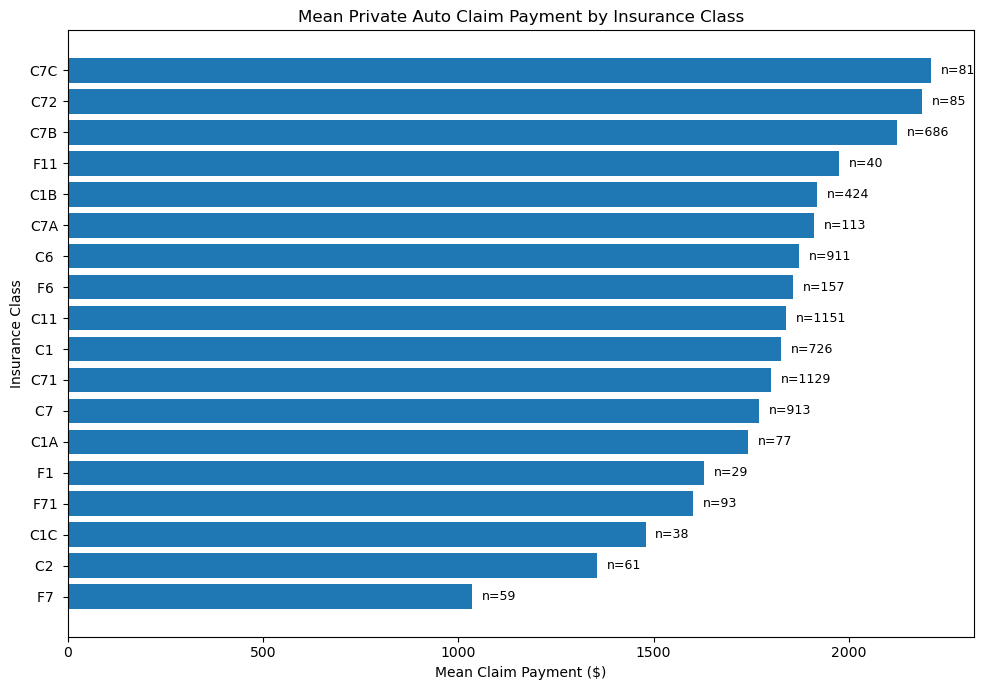

In [116]:
class_plot = class_severity.sort_values(
    "Mean_PAID",
    ascending=True
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    class_plot["CLASS"].astype(str),
    class_plot["Mean_PAID"]
)

plt.xlabel("Mean Claim Payment ($)")
plt.ylabel("Insurance Class")
plt.title("Mean Private Auto Claim Payment by Insurance Class")

for bar, count in zip(
    bars,
    class_plot["Count"]
):
    plt.text(
        bar.get_width() + 25,
        bar.get_y() + bar.get_height() / 2,
        f"n={count}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [117]:
fars_clean["RESTRAINT_GROUP"] = (
    fars_clean["RESTRAINT_GROUP"]
    .replace({
        "None Used": "None Used / Not Applicable"
    })
)

display(
    fars_clean["RESTRAINT_GROUP"]
    .value_counts()
)

RESTRAINT_GROUP
Restraint Used                46416
None Used / Not Applicable    23472
Unknown                        7362
Other                            35
Name: count, dtype: int64

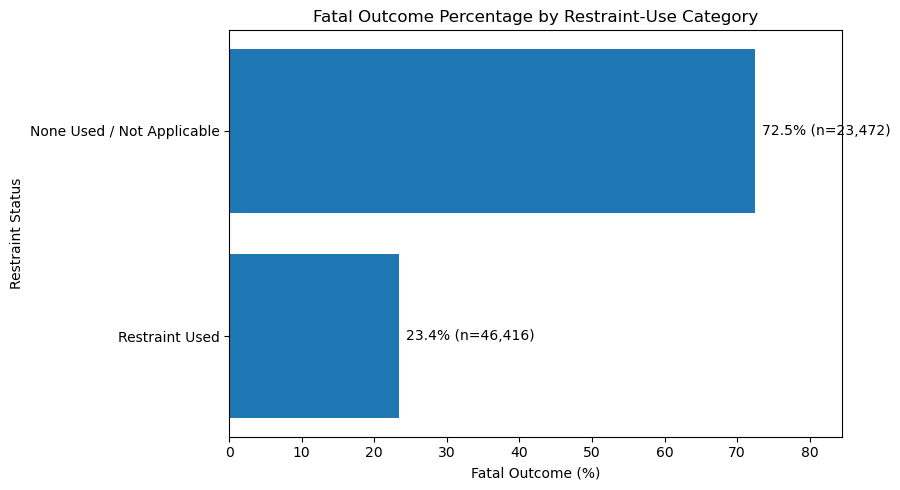

In [118]:
restraint_figure = (
    fars_clean
    .groupby("RESTRAINT_GROUP")["FATAL_OUTCOME"]
    .agg(["count", "sum"])
    .reset_index()
)

restraint_figure.columns = [
    "Restraint_Status",
    "Total",
    "Fatal"
]

restraint_figure["Fatal_Percentage"] = (
    restraint_figure["Fatal"] /
    restraint_figure["Total"] * 100
)

restraint_figure = restraint_figure[
    restraint_figure["Restraint_Status"].isin([
        "Restraint Used",
        "None Used / Not Applicable"
    ])
].sort_values("Fatal_Percentage")

plt.figure(figsize=(9, 5))

bars = plt.barh(
    restraint_figure["Restraint_Status"],
    restraint_figure["Fatal_Percentage"]
)

plt.xlabel("Fatal Outcome (%)")
plt.ylabel("Restraint Status")
plt.title("Fatal Outcome Percentage by Restraint-Use Category")

for bar, pct, count in zip(
    bars,
    restraint_figure["Fatal_Percentage"],
    restraint_figure["Total"]
):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}% (n={count:,})",
        va="center"
    )

plt.xlim(
    0,
    restraint_figure["Fatal_Percentage"].max() + 12
)

plt.tight_layout()
plt.show()

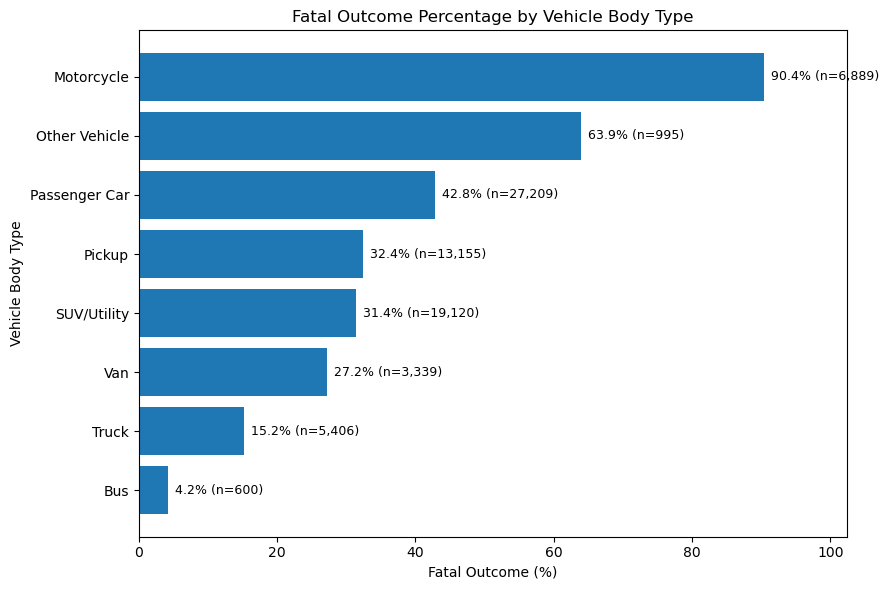

In [119]:
body_figure = (
    fars_clean
    .groupby("BODY_TYPE_GROUP")["FATAL_OUTCOME"]
    .agg(["count", "sum"])
    .reset_index()
)

body_figure.columns = [
    "Body_Type",
    "Total",
    "Fatal"
]

body_figure["Fatal_Percentage"] = (
    body_figure["Fatal"] /
    body_figure["Total"] * 100
)

body_figure = body_figure[
    ~body_figure["Body_Type"].isin([
        "Unknown"
    ])
].sort_values(
    "Fatal_Percentage"
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    body_figure["Body_Type"],
    body_figure["Fatal_Percentage"]
)

plt.xlabel("Fatal Outcome (%)")
plt.ylabel("Vehicle Body Type")
plt.title("Fatal Outcome Percentage by Vehicle Body Type")

for bar, pct, count in zip(
    bars,
    body_figure["Fatal_Percentage"],
    body_figure["Total"]
):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}% (n={count:,})",
        va="center",
        fontsize=9
    )

plt.xlim(
    0,
    body_figure["Fatal_Percentage"].max() + 12
)

plt.tight_layout()
plt.show()

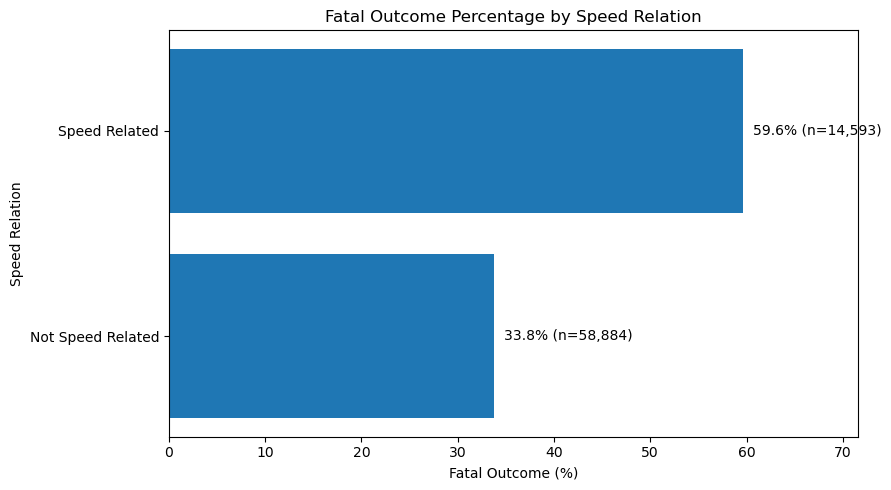

In [120]:
speed_figure = (
    fars_clean
    .groupby("SPEEDREL_GROUP")["FATAL_OUTCOME"]
    .agg(["count", "sum"])
    .reset_index()
)

speed_figure.columns = [
    "Speed_Relation",
    "Total",
    "Fatal"
]

speed_figure["Fatal_Percentage"] = (
    speed_figure["Fatal"] /
    speed_figure["Total"] * 100
)

speed_figure = speed_figure[
    speed_figure["Speed_Relation"].isin([
        "Not Speed Related",
        "Speed Related"
    ])
].sort_values(
    "Fatal_Percentage"
)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    speed_figure["Speed_Relation"],
    speed_figure["Fatal_Percentage"]
)

plt.xlabel("Fatal Outcome (%)")
plt.ylabel("Speed Relation")
plt.title("Fatal Outcome Percentage by Speed Relation")

for bar, pct, count in zip(
    bars,
    speed_figure["Fatal_Percentage"],
    speed_figure["Total"]
):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}% (n={count:,})",
        va="center"
    )

plt.xlim(
    0,
    speed_figure["Fatal_Percentage"].max() + 12
)

plt.tight_layout()
plt.show()